# ADNI Merge: Feature Deep Dive EDA

Focusing on these features listed in the sponsor's project description:
  - Demographics: Age, Sex, Education
  - Genetic: APOE4
  - CSF Biomarkers: ABETA, TAU, PTAU
  - Cognitive Scores: MMSE, LDELTOTAL (Logical Memory), CDRSB, ADAS11, ADAS13, RAVLT
  - MRI-derived: Hippocampus, Entorhinal, Ventricles, WholeBrain, Fusiform, MidTemp, ICV
  - Diagnosis: DX (current), DX_bl (baseline)

Run:
    pip install pandas matplotlib seaborn scipy scikit-learn --break-system-packages
    python adni_eda.py

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import roc_auc_score
import os
from scipy.stats import spearmanr
from scipy import stats as _stats

In [ ]:
# Configuration
DATA_PATH = "ADNIMERGE_28Feb2026.csv"
OUTPUT_DIR = "eda_figures"

os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
DX_ORDER   = ["CN", "MCI", "Dementia"]
DX_PALETTE = {"CN": "#2ecc71", "MCI": "#f39c12", "Dementia": "#e74c3c"}

# load
print("Loading data")
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"  Shape: {df.shape}  ({df['RID'].nunique()} unique subjects)")

Loading data
  Shape: (16421, 116)  (2430 unique subjects)


In [ ]:
# standardize DX labels
dx_remap = {
    "CN": "CN", "MCI": "MCI", "LMCI": "MCI", "EMCI": "MCI",
    "AD": "Dementia", "Dementia": "Dementia",
    "SMC": "CN"   #subjective memory concern which is treated as CNish
}
df["DX"]    = df["DX"].map(dx_remap)
df["DX_bl"] = df["DX_bl"].map(dx_remap)

# parse numeric CSF stuff (stored as strings with ">" and "<")
for col in ["ABETA", "TAU", "PTAU", "ABETA_bl", "TAU_bl", "PTAU_bl"]:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(">", "").str.replace("<", "").str.strip(),
        errors="coerce"
    )

# feature groups
DEMO_FEATURES   = ["AGE", "PTEDUCAT"]
COG_FEATURES    = ["MMSE", "CDRSB", "ADAS11", "ADAS13", "LDELTOTAL",
                   "RAVLT_immediate", "RAVLT_learning", "RAVLT_forgetting", "FAQ"]
CSF_FEATURES    = ["ABETA", "TAU", "PTAU"]
MRI_FEATURES    = ["Hippocampus", "Entorhinal", "Ventricles",
                   "WholeBrain", "Fusiform", "MidTemp", "ICV"]
KEY_FEATURES    = DEMO_FEATURES + COG_FEATURES + CSF_FEATURES + MRI_FEATURES

# baseline only df (one row per subject)
df_bl = df[df["VISCODE"] == "bl"].copy()
print(f"  Baseline subjects: {len(df_bl)}")

  Baseline subjects: 2430


# Chart 1: Dataset Overview


---


### Purpose & Variables:
Three panels that establish the basic shape of the dataset. The left panel is a histogram of how many total study visits each of the 2,430 subjects has contributed. The center panel is a bar chart of the baseline diagnosis breakdown (Cognitively Normal (CN), Mild Cognitive Impairment (MCI), and Dementia) showing how many subjects fall into each class at enrollment. The right panel breaks each diagnosis group down further by biological sex.


---



### Analysis:
The visit histogram is heavily right-skewed: the largest spike is at 1–2 visits, meaning a substantial chunk of subjects dropped out early, were enrolled late in the study. Most subjects cluster between 2 and 10 visits, with a small but meaningful tail extending all the way to 25 (those are mainly ADNI1 subjects who have been followed since the study launched in 2004). The mean of 6.8 visits with a median of 5 confirms the skew. This matters for modeling since irregular and unequal sequence lengths are the norm in this dataset, not the exception.

The class distribution in the center panel reveals a meaningful imbalance. MCI is the largest group at approx 1,113 subjects (46%), CN is second at approx 895 (37%), and Dementia is the smallest at approximately 411 (17%). This imbalance will require handling during model training either via class weighting, oversampling, or stratified splits to prevent the model from learning to ignore the minority Dementia class.

The sex breakdown on the right shows that CN skews slightly female, MCI skews heavily male, and Dementia is roughly 55% male / 45% female. The male skew in MCI in particular is worth noting. It could be a genuine epidemiological signal (men may be more likely to be referred for MCI evaluation) or it may reflect recruitment bias in ADNI's early phases. This is a confounding variable that demographic feature inclusion can help control for.

In [ ]:
# 1. dataset overview
print("\n 1. dataset overview")

# visits per subject
visits_per_subj = df.groupby("RID").size()
print(f"  visits per subject  (mean): {visits_per_subj.mean():.1f}, "
      f"median: {visits_per_subj.median():.0f}, max: {visits_per_subj.max()}")

# diagnosis distribution
print("\n  Baseline DX distribution:")
print(df_bl["DX_bl"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) visits histogram
axes[0].hist(visits_per_subj, bins=20, color="#3498db", edgecolor="white")
axes[0].set(title="Visits per Subject", xlabel="Number of Visits", ylabel="Subjects")

# (b) baseline DX
dx_counts = df_bl["DX_bl"].value_counts().reindex(DX_ORDER, fill_value=0)
axes[1].bar(dx_counts.index, dx_counts.values,
            color=[DX_PALETTE[d] for d in dx_counts.index], edgecolor="white")
axes[1].set(title="Baseline Diagnosis Distribution", ylabel="Count")

# (c) sex by DX
sex_dx = df_bl.groupby(["DX_bl", "PTGENDER"]).size().unstack(fill_value=0)
sex_dx = sex_dx.reindex(DX_ORDER)
sex_dx.plot(kind="bar", ax=axes[2], color=["#e74c3c", "#3498db"], edgecolor="white", rot=0)
axes[2].set(title="Sex by Baseline Diagnosis", ylabel="Count")
axes[2].legend(title="Sex")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_overview.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 01_overview.png")


 1. dataset overview
  visits per subject  (mean): 6.8, median: 5, max: 25

  Baseline DX distribution:
DX_bl
MCI         1113
CN           895
Dementia     411
Name: count, dtype: int64
  Saved: 01_overview.png


# Chart 2: Missingness by Feature


---


### Purpose & Variables:
A horizontal bar chart ranking every key project feature from least to most missing across the full 16,421 row dataset. The orange dashed line marks 20% missing (moderate concern) and the red dashed line marks 50% (severe concern and likely unusable as a primary feature without imputation strategy). Color coded: green = <20%, orange = 20–50%, red = >50%.


---


### Analysis:
The chart separates clearly into three tiers. At the bottom (least missing), education (PTEDUCAT) and age (AGE) are essentially complete which makes sense because demographic features are recorded at enrollment and don't vary per visit. Cognitive scores like CDRSB, FAQ, MMSE, and the ADAS and RAVLT batteries all cluster around 28–31% missing, which is moderate and manageable, primarily because these tests weren't administered at every visit type across all ADNI phases.
MRI derived volumetric features (Hippocampus, Entorhinal, Fusiform, MidTemp) sit just under the 50% red line, right around 46–49% missing. This is higher than it might look at baseline (the baseline-specific missingness table in the script output showed only 10–22% missing at the first visit)  meaning the bulk of this missingness accumulates across follow up visits where MRI scans weren't collected. The MRI features are usable but require a clear imputation or "last observation carried forward" strategy for longitudinal models.
The CSF biomarkers (ABETA, TAU, and PTAU) are the critical flag in this chart, all sitting at  about 86% missing across the full dataset. Even at baseline, they're 44–59% missing depending on diagnosis group. Lumbar punctures are invasive and optional, so many subjects simply never had them. This means CSF cannot be a core input feature for any model that needs to generalize, it must be treated as an auxiliary feature available only for a subset of subjects, or we needs a dedicated imputation or multimodal dropout approach as discussed in the comprehensive research document on the drive.

In [ ]:
# 2. missingness analysis
print("\n 2. Missingness")

miss = df[KEY_FEATURES].isnull().mean().sort_values(ascending=False) * 100
print(miss.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if v > 50 else "#f39c12" if v > 20 else "#2ecc71" for v in miss]
ax.barh(miss.index, miss.values, color=colors, edgecolor="white")
ax.axvline(50, color="red", linestyle="--", linewidth=1, label="50% threshold")
ax.axvline(20, color="orange", linestyle="--", linewidth=1, label="20% threshold")
ax.set(title="Missing Data by Feature (full dataset)", xlabel="% Missing")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_missingness.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 02_missingness.png")


# Missingness by DX at baseline
print("\n  baseline missingness by DX (in %):")
miss_by_dx = (df_bl.groupby("DX_bl")[KEY_FEATURES]
              .apply(lambda x: x.isnull().mean() * 100)
              .T.round(1))
print(miss_by_dx.to_string())


 2. Missingness
PTAU                85.573351
ABETA               85.567261
TAU                 85.567261
Entorhinal          48.602399
Fusiform            48.602399
MidTemp             48.602399
Hippocampus         46.087327
LDELTOTAL           42.500457
Ventricles          42.342123
WholeBrain          40.673528
ICV                 38.402046
RAVLT_forgetting    31.094330
ADAS13              31.002984
RAVLT_immediate     30.905548
RAVLT_learning      30.899458
ADAS11              30.387918
MMSE                30.156507
FAQ                 28.487912
CDRSB               28.463553
AGE                  0.054808
PTEDUCAT             0.000000
  Saved: 02_missingness.png

  baseline missingness by DX (in %):
DX_bl               CN  Dementia   MCI
AGE                0.1       0.0   0.3
PTEDUCAT           0.0       0.0   0.0
MMSE               0.1       0.0   0.0
CDRSB              0.0       0.0   0.0
ADAS11             0.2       0.5   0.5
ADAS13             0.4       2.2   0.8
LDELTOTAL     

# Chart 3: Demographics


---


### Purpose & Variables:
Three panels examining how the demographic and genetic features distribute across diagnosis groups at baseline. Left: overlapping histograms of age by DX. Center: boxplots of years of education. Right: grouped bar chart of APOE4 allele count (0, 1, or 2 copies of the risk allele) by DX.


---


### Analysis:
The age histograms show considerable overlap across all three groups (all peak roughly in the 68–78 range). Dementia subjects skew slightly older (mean 74.7 vs 72.2 for CN), which is expected, but the difference is modest and the distributions overlap substantially. Age alone is a weak predictor of diagnosis status, which is confirmed later in Chart 10 (AUROC only 0.61). The practical implication is that age will serve more as a covariate for control than as a primary discriminating feature.

Education is nearly identical across groups with all three have medians right around 16 years (college level). This is a known limitation of ADNI: it recruited a highly educated, predominantly white volunteer population, which limits generalizability. Education's AUROC is similarly weak at 0.63. It is included in models mainly as a proxy for cognitive reserve, not as a direct predictor.

The APOE4 panel is the most clinically important of the three. The gradient is unmistakable: subjects with zero risk alleles dominate the CN group (roughly 550 out of  about 895), while the 1 allele and especially 2 allele counts grow progressively as you move from CN  to  MCI  to  Dementia. Specifically, the prevalence of having at least one APOE4 allele goes from 31% in CN to 50% in MCI to 67% in Dementia. The 2 allele (homozygous) count, while small in absolute numbers, approximately triples from CN to Dementia. APOE4 is a binary(ish) risk flag rather than a continuous measure of severity, which is why its AUROC (0.70) is decent but not as strong as continuous biomarkers.

In [ ]:
# 3. demographics
print("\n 3. Demographics")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# age distribution by DX
for dx in DX_ORDER:
    sub = df_bl[df_bl["DX_bl"] == dx]["AGE"].dropna()
    axes[0].hist(sub, bins=20, alpha=0.6, label=dx, color=DX_PALETTE[dx])
axes[0].set(title="Age Distribution by Diagnosis", xlabel="Age", ylabel="Count")
axes[0].legend()

# Age stats
print("\n  Age by DX_bl:")
print(df_bl.groupby("DX_bl")["AGE"].describe().round(1).to_string())

# education by DX
ed_data = [df_bl[df_bl["DX_bl"] == dx]["PTEDUCAT"].dropna() for dx in DX_ORDER]
axes[1].boxplot(ed_data, labels=DX_ORDER,
                patch_artist=True,
                boxprops=dict(facecolor="#dfe6e9"))
axes[1].set(title="Years of Education by Diagnosis", ylabel="Years")

# APOE4 by DX
apoe_dx = df_bl.dropna(subset=["APOE4", "DX_bl"])
apoe_counts = apoe_dx.groupby(["DX_bl", "APOE4"]).size().unstack(fill_value=0)
apoe_counts = apoe_counts.reindex(DX_ORDER)
apoe_counts.columns = ["0 alleles", "1 allele", "2 alleles"]
apoe_counts.plot(kind="bar", ax=axes[2],
                 color=["#2ecc71", "#f39c12", "#e74c3c"], edgecolor="white", rot=0)
axes[2].set(title="APOE4 Alleles by Diagnosis", ylabel="Count")
axes[2].legend(title="APOE4")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_demographics.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 03_demographics.png")

# APOE4 prevalence
print("\n  APOE4 ≥1 allele by DX_bl (%):")
apoe_prev = (apoe_dx.assign(has_apoe=lambda x: x["APOE4"] >= 1)
             .groupby("DX_bl")["has_apoe"].mean() * 100).round(1)
print(apoe_prev.reindex(DX_ORDER))


 3. Demographics

  Age by DX_bl:
           count  mean  std   min   25%   50%   75%   max
DX_bl                                                    
CN         894.0  72.2  6.7  50.4  67.5  72.0  76.7  90.3
Dementia   411.0  74.7  7.9  55.1  70.2  75.3  80.3  90.9
MCI       1110.0  72.8  7.6  54.4  67.6  73.1  78.2  91.4
  Saved: 03_demographics.png

  APOE4 ≥1 allele by DX_bl (%):
DX_bl
CN          30.7
MCI         49.6
Dementia    67.1
Name: has_apoe, dtype: float64


# Chart 4: Cognitive Scores


---


### Purpose & Variables:
A 2×3 grid of notched boxplots, one per cognitive test, comparing distributions across CN, MCI, and Dementia at baseline. The six tests shown are:

- MMSE (Mini-Mental State Examination): 0–30, higher is better
- CDR-SB (Clinical Dementia Rating Sum of Boxes): 0–18, lower is better
- ADAS-11 (Alzheimer's Disease Assessment Scale): 0–70, lower is better
- Logical Memory (LDELTOTAL): paragraph recall score, higher is better
- RAVLT Immediate: word list recall across 5 trials summed, higher is better
- FAQ (Functional Activities Questionnaire): 0–30, lower is better


---


### Analysis:
Every single one of these six tests shows highly statistically significant separation across DX groups (all  p-values < 10⁻²¹⁵). The question is not whether they separate (they clearly do), but the quality and nature of that separation.

MMSE is the most familiar clinically but shows notably wide IQR in the Dementia group (roughly 21–25) with a long lower whisker reaching below 16. The notch widths indicate the MCI-CN gap is narrower than MCI–Dementia, confirming that MMSE struggles most at distinguishing CN from early MCI (medians of 29 vs. 28). CDR-SB is almost perfectly separated: CN median is 0 (most patients are essentially asymptomatic), MCI median is  about 1.5, and Dementia median is  about 4.5, with very compact CN and MCI boxes. This is why CDR-SB scores a near-perfect AUROC of 1.00 in Chart 10.

Logical Memory (LDELTOTAL) tells the clearest biological story. The Dementia group median is essentially 0 (meaning most patients with dementia cannot recall any of the story paragraphs at all) versus a CN median of  about 13. The MCI group spans the widest range (0–18), reflecting the heterogeneity within MCI. Memory recall is the feature most directly tied to hippocampal function, which explains its extremely strong discriminability.

FAQ is noteworthy because it is the only support-person rated test (caregiver answers about daily functioning) rather than direct patient performance. It compresses CN patients tightly near 0 (caregivers report no functional impairment) while Dementia patients are spread from about 9–18. It's highly discriminating but may be less useful for pure biomarker driven models since it requires an informant, making it partially target-leaky in progression prediction settings.


In [ ]:
# 4. cognitive scores
print("\n 4. cognitive scores")

cog_labels = {
    "MMSE": "MMSE (0–30, higher = better)",
    "CDRSB": "CDR-SB (0–18, lower = better)",
    "ADAS11": "ADAS-11 (0–70, lower = better)",
    "LDELTOTAL": "Logical Memory (higher = better)",
    "RAVLT_immediate": "RAVLT Immediate (higher = better)",
    "FAQ": "FAQ (0–30, lower=better)"
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(cog_labels.items()):
    data_by_dx = [df_bl[df_bl["DX_bl"] == dx][col].dropna() for dx in DX_ORDER]
    bp = axes[i].boxplot(data_by_dx, labels=DX_ORDER, patch_artist=True, notch=True,
                         medianprops=dict(color="black", linewidth=2))
    for patch, dx in zip(bp["boxes"], DX_ORDER):
        patch.set_facecolor(DX_PALETTE[dx])
        patch.set_alpha(0.8)
    axes[i].set(title=label, ylabel="Score")

plt.suptitle("Cognitive Scores by Baseline Diagnosis", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_cognitive_scores.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 04_cognitive_scores.png")

# stat tests
print("\n  Kruskal-Wallis tests (DX group differences):")
for col in list(cog_labels.keys()):
    groups = [df_bl[df_bl["DX_bl"] == dx][col].dropna() for dx in DX_ORDER]
    groups = [g for g in groups if len(g) > 5]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        print(f"    {col}: H={stat:.1f}, p={p:.2e} {'***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''}")

# summary stats
print("\n  Cognitive score summary (baseline):")
print(df_bl.groupby("DX_bl")[list(cog_labels.keys())].median().round(2).reindex(DX_ORDER).to_string())


 4. cognitive scores
  Saved: 04_cognitive_scores.png

  Kruskal-Wallis tests (DX group differences):
    MMSE: H=1156.0, p=9.71e-252 ***
    CDRSB: H=2008.8, p=0.00e+00 ***
    ADAS11: H=1186.0, p=2.85e-258 ***
    LDELTOTAL: H=1584.5, p=0.00e+00 ***
    RAVLT_immediate: H=991.6, p=4.65e-216 ***
    FAQ: H=1347.0, p=3.25e-293 ***

  Cognitive score summary (baseline):
          MMSE  CDRSB  ADAS11  LDELTOTAL  RAVLT_immediate   FAQ
DX_bl                                                          
CN        29.0    0.0    5.33       13.0             45.0   0.0
MCI       28.0    1.5    9.67        6.0             33.0   1.0
Dementia  23.0    4.5   19.00        0.0             23.0  13.0


# Chart 5: CSF Biomarkers


---


### Purpose & Variables:
Three boxplots showing the distribution of the three key cerebrospinal fluid biomarkers by baseline diagnosis. All values are in pg/mL.

- ABETA (Aβ42): amyloid-beta protein. Low values indicate amyloid plaque accumulation in the brain. lower is more pathological.
- TAU (total tau): overall burden of tau protein. High values indicate neurodegeneration. higher is more pathological.
- PTAU (phosphorylated tau): specifically the tau form that forms neurofibrillary tangles. Same direction as TAU, higher is worse.

Only  about 14% of the full dataset has CSF data, so these distributions reflect a biased subset of subjects who consented to lumbar puncture.


---


### Analysis:
ABETA shows a clear downward gradient from CN  to  MCI  to  Dementia: CN median is  about 1,271 pg/mL, MCI median is  about 837 pg/mL, Dementia median is  about 594 pg/mL. However, the CN box is extremely wide (the IQR spans roughly 820 to 1,700) reflecting that many cognitively normal subjects already have amyloid accumulation (what researchers call "preclinical AD"). There's substantial overlap between all three groups, particularly CN and MCI. This supports the hypothesis that amyloid accumulation precedes clinical symptoms by years, meaning ABETA is not a clean diagnostic marker but may be highly predictive of future conversion.

TAU and PTAU mirror each other almost perfectly, they have a correlation of 0.98 as seen in the heatmap. Both show modest elevation in MCI relative to CN, and a clearer jump in Dementia. The distributions are more right-skewed than ABETA, with notable outliers in the MCI group reaching TAU values over 1,000 pg/mL. The weaker group separation in TAU vs. ABETA (particularly the large overlap between CN and MCI) means tau is less useful as a standalone discriminator early in the disease, but the combination of all three biomarkers (referred to as the "ATN framework") is much more informative than any single one.

The amyloid-positivity rate (ABETA < 980 pg/mL) in CN subjects is 15%, in MCI is 34%, and in Dementia is 49% (and the Dementia rate being only 49% is counterintuitive). It likely reflects the subset bias of who gets a lumbar puncture: sicker Dementia patients may be less likely to consent, selecting for a healthier subsample. This self-selection bias is important to flag.

In [ ]:
# 5. CSF biomarkers
print("\n 5. CSF Biomarkers")

csf_labels = {
    "ABETA": "Amyloid-β (Aβ42), lower = more pathology",
    "TAU":   "Total Tau, higher = more pathology",
    "PTAU":  "Phospho-Tau, higher = more pathology"
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (col, label) in enumerate(csf_labels.items()):
    data_by_dx = [df_bl[df_bl["DX_bl"] == dx][col].dropna() for dx in DX_ORDER]
    bp = axes[i].boxplot(data_by_dx, labels=DX_ORDER, patch_artist=True, notch=False,
                         medianprops=dict(color="black", linewidth=2))
    for patch, dx in zip(bp["boxes"], DX_ORDER):
        patch.set_facecolor(DX_PALETTE[dx])
        patch.set_alpha(0.8)
    axes[i].set(title=col, ylabel="pg/mL")
    axes[i].text(0.02, 0.98, label, transform=axes[i].transAxes,
                 fontsize=8, va="top", color="gray")

plt.suptitle("CSF Biomarkers by Baseline Diagnosis", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_csf_biomarkers.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 05_csf_biomarkers.png")

print("\n  CSF summary stats (baseline, by DX):")
print(df_bl.groupby("DX_bl")[CSF_FEATURES].describe().round(1).to_string())

print("\n  CSF Kruskal-Wallis tests:")
for col in CSF_FEATURES:
    groups = [df_bl[df_bl["DX_bl"] == dx][col].dropna() for dx in DX_ORDER]
    groups = [g for g in groups if len(g) > 5]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        print(f"    {col}: H={stat:.1f}, p={p:.2e}")

# ABETA positive rate (< 980 is a often used threshold for positivity)
df_bl["amyloid_pos"] = df_bl["ABETA"] < 980
print("\n  Amyloid+ rate by DX (ABETA < 980 pg/mL):")
print((df_bl.groupby("DX_bl")["amyloid_pos"].mean() * 100).round(1).reindex(DX_ORDER))


 5. CSF Biomarkers
  Saved: 05_csf_biomarkers.png

  CSF summary stats (baseline, by DX):
          ABETA                                                         TAU                                                    PTAU                                          
          count    mean    std    min    25%     50%     75%     max  count   mean    std   min    25%    50%    75%     max  count  mean   std  min   25%   50%   75%    max
DX_bl                                                                                                                                                                        
CN        367.0  1205.1  443.9  200.0  820.8  1271.0  1700.0  1700.0  367.0  237.4   90.7  80.0  175.2  214.3  287.8   590.1  367.0  21.8   9.3  8.0  15.5  19.4  26.3   60.0
Dementia  229.0   669.1  315.7  212.3  469.8   593.6   756.9  1700.0  229.0  367.0  145.8  80.0  268.1  338.4  440.2   851.6  229.0  36.6  15.8  8.0  25.7  33.6  44.4   94.9
MCI       619.0   961.4  437.2  210.9  

# Chart 6: MRI Volumetric Features


---


### Purpose & Variables:
Five boxplots of MRI-derived brain region volumes, each normalized by intracranial volume (ICV) to control for differences in head size across subjects. The y-axis shows volume as a percentage of total brain cavity. The regions are:

Hippocampus / ICV: primary memory hub; earliest to atrophy in AD
Entorhinal / ICV: input/output gateway of the hippocampus; among the first regions affected
Ventricles / ICV: fluid-filled spaces; expand as brain tissue is lost (inverted signal — higher = more atrophy)
Fusiform / ICV: temporal lobe region involved in face/object recognition
Mid Temporal / ICV: broader temporal lobe region affected in later-stage AD


---


### Analysis:
The hippocampus and entorhinal cortex show the most dramatic and cleanest separation. Hippocampal volume goes from a CN median of  about 0.50% ICV down to  about 0.44% in MCI and  about 0.38% in Dementia — a roughly 24% reduction from healthy to Dementia. The boxes are compact and barely overlapping. This is the strongest MRI biomarker in the dataset (AUROC 0.91) and is directly tied to the memory deficits seen in Chart 04. Entorhinal cortex follows a similar pattern but with slightly more noise.
The ventricle panel tells the same story in reverse, as expected: CN subjects have ventricles comprising  about 2% of ICV, MCI subjects  about 2.5%, and Dementia subjects  about 3%. The spread in the Dementia group is wide, reflecting that ventricular enlargement is a later-stage marker and varies considerably depending on disease duration and individual anatomy.
Fusiform and Mid Temporal show the same direction of effect (volume decreases with severity) but with more overlap between groups, particularly between MCI and Dementia. This is consistent with what the research literature shows: these areas are affected in later stages, so they're less useful for early detection or MCI conversion prediction but may become important for tracking later-stage progression.
One important note: all of these volumes are derived from FreeSurfer processing of T1-weighted MRI scans, and the MRI data itself spans both 1.5T and 3T field strength scanners across ADNI phases. That difference introduces systematic measurement bias that normalization by ICV does not fully correct — something the team will need to handle carefully in modeling.

In [ ]:
# 6.MRI features about volume
print("\n 6. MRI Volumetric features")

# normalize volumes (ICV)
for col in ["Hippocampus", "Entorhinal", "Ventricles", "Fusiform", "MidTemp", "WholeBrain"]:
    df_bl[f"{col}_ICV"] = df_bl[col] / df_bl["ICV"]

mri_norm = ["Hippocampus_ICV", "Entorhinal_ICV", "Ventricles_ICV",
            "Fusiform_ICV", "MidTemp_ICV"]
mri_labels = {
    "Hippocampus_ICV": "Hippocampus / ICV",
    "Entorhinal_ICV":  "Entorhinal / ICV",
    "Ventricles_ICV":  "Ventricles / ICV (↑ = atrophy)",
    "Fusiform_ICV":    "Fusiform / ICV",
    "MidTemp_ICV":     "Mid Temporal / ICV"
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, (col, label) in enumerate(mri_labels.items()):
    data_by_dx = [df_bl[df_bl["DX_bl"] == dx][col].dropna() * 100 for dx in DX_ORDER]
    bp = axes[i].boxplot(data_by_dx, labels=DX_ORDER, patch_artist=True, notch=False,
                         medianprops=dict(color="black", linewidth=2))
    for patch, dx in zip(bp["boxes"], DX_ORDER):
        patch.set_facecolor(DX_PALETTE[dx])
        patch.set_alpha(0.8)
    axes[i].set(title=label, ylabel="% of ICV")
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle("ICV-Normalized MRI Volumes by Baseline Diagnosis", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_mri_volumes.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 06_mri_volumes.png")

print("\n  MRI volumes — raw summary (baseline by DX):")
print(df_bl.groupby("DX_bl")[["Hippocampus", "Entorhinal", "Ventricles"]].describe().round(0).to_string())

print("\n  MRI Kruskal-Wallis tests (ICV-normalized):")
for col in mri_norm:
    groups = [df_bl[df_bl["DX_bl"] == dx][col].dropna() for dx in DX_ORDER]
    groups = [g for g in groups if len(g) > 5]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        print(f"    {col}: H={stat:.1f}, p={p:.2e}")


 6. MRI Volumetric features
  Saved: 06_mri_volumes.png

  MRI volumes — raw summary (baseline by DX):
         Hippocampus                                                          Entorhinal                                                        Ventricles                                                               
               count    mean     std     min     25%     50%     75%      max      count    mean    std     min     25%     50%     75%     max      count     mean      std     min      25%      50%      75%       max
DX_bl                                                                                                                                                                                                                    
CN             800.0  7491.0   882.0  4238.0  6940.0  7516.0  8012.0  10769.0      796.0  3975.0  674.0  1870.0  3520.0  3940.0  4381.0  6273.0      824.0  32766.0  18138.0  5834.0  19935.0  28161.0  40797.0  118875.0
Dementia       338.0  57

# Chart 7: Correlation Heatmap


---


### Purpose & Variables:
A lower-triangular heatmap of pairwise Spearman rank correlations computed at baseline across all key project features. Spearman is used rather than Pearson because many features are non-normally distributed or ordinal. Red cells indicate positive correlation, blue indicates negative, and white near-zero. Values are annotated directly.


---


### Analysis:
The most immediately striking cell is the TAU–PTAU correlation of 0.98 — these two biomarkers are nearly perfectly redundant with each other. Using both in a model simultaneously will cause severe multicollinearity and likely one should be dropped or they should be combined into a ratio. This is an important data decision to flag.
Among cognitive scores, CDRSB and ADAS11 correlate at 0.69, and both correlate negatively with MMSE (around –0.66) and LDELTOTAL (around –0.79 to –0.73). FAQ stands out as the most highly correlated with the other cognitive measures (CDRSB r=0.80, ADAS11 r=0.64), reinforcing that it captures the same underlying construct. From a feature selection standpoint, you likely do not need all six cognitive tests simultaneously — a subset of 2–3 would capture most of the variance.
The MRI features tell an interesting story: Hippocampus_ICV and Entorhinal_ICV correlate at 0.67 with each other but only moderately with cognitive scores (around 0.42–0.55 with MMSE, –0.48 to –0.57 with CDRSB). This moderate cross-domain correlation is actually a good sign — it means MRI features are contributing independent information beyond what cognitive scores already capture, which is what motivates using both in multimodal models. Ventricles_ICV shows the expected negative correlation with hippocampus (–0.60), as brain atrophy and CSF expansion are two sides of the same coin.
APOE4's correlations are modest across the board (0.20–0.36 range), consistent with it being a risk factor rather than a direct severity measure. Age correlates negatively with hippocampal volume (–0.42), which reflects normal aging — an important confound the model needs to account for since you don't want it learning "old people have smaller hippocampi" and confusing that with disease.

In [ ]:
# 7. correlation heatmap
print("\n 7. correlation heatmap")

corr_features = ["AGE", "PTEDUCAT", "APOE4",
                 "MMSE", "CDRSB", "ADAS11", "LDELTOTAL", "RAVLT_immediate", "FAQ",
                 "ABETA", "TAU", "PTAU",
                 "Hippocampus_ICV", "Entorhinal_ICV", "Ventricles_ICV"]

corr_df = df_bl[corr_features].copy()
corr_matrix = corr_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={"size": 8})
ax.set_title("Spearman Correlations (Baseline) — Key Features", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 07_correlation_heatmap.png")


 7. correlation heatmap
  Saved: 07_correlation_heatmap.png


# Chart 8: Longitudinal Trajectories


---


### Purpose & Variables:
Four line plots (MMSE, Hippocampal Volume, CDR-SB, and CSF Amyloid-β) showing how the mean value of each feature evolves over 8 years of follow-up, grouped by baseline diagnosis. The shaded band around each line is the standard error of the mean (SEM), giving a sense of variability in the trajectory. The x-axis is years since the baseline visit.

### Analysis:
The MMSE and CDR-SB plots show what you'd expect and want to see: clean, consistent trajectories where the groups diverge progressively over time. CN subjects remain essentially flat — MMSE stays around 28.8 and CDR-SB barely moves off zero — confirming the healthy controls are genuinely stable. MCI subjects show a slow, consistent decline in MMSE (27  to   about 25.5 over 8 years) and a gradual increase in CDR-SB (1.8  to   about 4). The Dementia group declines most steeply in both, with CDR-SB reaching  about 12 by year 8. The maintained separation and smooth trajectories are a strong signal that longitudinal models have real structure to learn here.
The Hippocampal Volume trajectory shows the characteristic shrinkage pattern. CN subjects lose volume slowly (7,400  to   about 6,900 mm³ over 8 years), MCI subjects decline faster, and Dementia subjects start lower and continue declining. The SEM bands are narrow for CN and MCI through year 6, then widen in years 7–8 — this reflects the survivor bias as the cohort shrinks. Subjects still present at 8 years are a healthier, more compliant subset of the original group, so be cautious interpreting late time points.
The CSF Amyloid-β plot is the most irregular and has the widest confidence bands, which is exactly what you'd expect given the 86% missingness. The sporadic measurement timing means very few subjects contribute to each time point. The apparent rise in MCI amyloid at years 7–8 is almost certainly a sampling artifact — only a handful of subjects with high amyloid happen to be represented at that time point, not a true biological reversal. The irregular nature of this plot is itself informative: it confirms CSF cannot support longitudinal trajectory modeling the way MRI and cognitive scores can.

In [ ]:
# longitudinal trajectories
print("\n 8. Longitudinal Trajectories ")

long_features = {
    "MMSE": "MMSE Score",
    "Hippocampus": "Hippocampal Volume (mm³)",
    "CDRSB": "CDR Sum of Boxes",
    "ABETA": "CSF Amyloid-β (pg/mL)"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(long_features.items()):
    ax = axes[i]
    # Group by Month_bl bucket and DX_bl
    df_long = df.dropna(subset=[col, "DX_bl", "Years_bl"]).copy()
    df_long["Year_bucket"] = df_long["Years_bl"].round(0).astype(int)
    df_long = df_long[df_long["Year_bucket"] <= 8]

    traj = (df_long.groupby(["DX_bl", "Year_bucket"])[col]
            .agg(["mean", "sem"]).reset_index())

    for dx in DX_ORDER:
        sub = traj[traj["DX_bl"] == dx]
        if len(sub) < 2:
            continue
        ax.plot(sub["Year_bucket"], sub["mean"], marker="o",
                label=dx, color=DX_PALETTE[dx])
        ax.fill_between(sub["Year_bucket"],
                        sub["mean"] - sub["sem"],
                        sub["mean"] + sub["sem"],
                        alpha=0.2, color=DX_PALETTE[dx])

    ax.set(title=label, xlabel="Years from Baseline", ylabel=label)
    ax.legend()

plt.suptitle("Longitudinal Feature Trajectories by Baseline Diagnosis\n(mean ± SEM)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_longitudinal_trajectories.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 08_longitudinal_trajectories.png")


 8. Longitudinal Trajectories 
  Saved: 08_longitudinal_trajectories.png


# Chart 9: MCI Conversion Analysis


---


### Purpose & Variables:
Four violin plots comparing the baseline feature distributions of MCI subjects who eventually converted to Dementia ("Converters," red) versus those who remained MCI throughout their study participation ("Stable MCI," green). The four features shown are MMSE, CDR-SB, Hippocampus/ICV, and ABETA. The width of the violin at any given value shows how many subjects had that value.

### Analysis:
Out of 1,113 baseline MCI subjects, 385 (35%) converted to Dementia at some point during follow-up. This is the actual prediction target for the project — can you identify those 385 at baseline before conversion happens?
The MMSE violins overlap substantially (both center around 27–28), which confirms MMSE is a poor predictor of conversion within the MCI group. The difference in medians is statistically significant (p < 10⁻¹⁴) but the distributions are far too similar to be clinically useful on their own.
CDR-SB is more informative — Converters have a wider violin that extends further toward higher scores (worse function), with the bulk shifted slightly upward relative to Stable MCI. The median difference (2.0 vs. 1.0) is meaningful but the overlap is still large. CDR-SB captures current severity, not future trajectory.
Hippocampus/ICV is where things get more interesting. The Converter violin is visibly shifted downward relative to Stable MCI — Converters have smaller hippocampi at baseline even before conversion. The Stable MCI violin has a fatter upper region (more subjects with larger volumes). This is the type of biomarker signal that a longitudinal model could exploit: not just the baseline value, but how quickly it's declining.
ABETA is the most discriminating among these four for conversion. The Stable MCI violin is tall and fat toward the top — most Stable MCI subjects have high amyloid-beta (meaning healthy, low plaque burden). The Converter violin is shifted strongly downward, with the bulk of subjects clustering below  about 800 pg/mL. This is exactly what the ATN framework predicts: amyloid positivity precedes and predicts progression. Despite its missingness problem, ABETA is highly valuable where it exists.

In [ ]:
# 9. conversion analysis
print("\n 9. Conversion Analysis from MCI to Dementia")

# pts who start as MCI
mci_subjects = df_bl[df_bl["DX_bl"] == "MCI"]["RID"].unique()
mci_df = df[df["RID"].isin(mci_subjects)].copy()

#see if they ever convert
converters = mci_df[mci_df["DX"] == "Dementia"]["RID"].unique()
df_bl.loc[df_bl["RID"].isin(mci_subjects), "converted"] = \
    df_bl.loc[df_bl["RID"].isin(mci_subjects), "RID"].isin(converters)

mci_bl = df_bl[df_bl["DX_bl"] == "MCI"].dropna(subset=["converted"]).copy()
n_conv   = int(mci_bl["converted"].sum())
n_stable = int(( about mci_bl["converted"]).sum())
print(f"  MCI converters: {int(n_conv)}, Stable MCI: {int(n_stable)}, "
      f"Conversion rate: {n_conv/(n_conv+n_stable)*100:.1f}%")

conv_features = ["AGE", "APOE4", "MMSE", "CDRSB", "LDELTOTAL",
                 "ABETA", "TAU", "PTAU", "Hippocampus_ICV", "Entorhinal_ICV"]
conv_features = [f for f in conv_features if f in mci_bl.columns]

print("\n  baseline feature comparison, MCI Converters vs. Stable:")
for col in conv_features:
    grp_conv   = mci_bl[mci_bl["converted"] == True][col].dropna()
    grp_stable = mci_bl[mci_bl["converted"] == False][col].dropna()
    if len(grp_conv) < 5 or len(grp_stable) < 5:
        continue
    stat, p = mannwhitneyu(grp_conv, grp_stable, alternative="two-sided")
    direction = "↑" if grp_conv.median() > grp_stable.median() else "↓"
    print(f"    {col:25s}: Converter={grp_conv.median():.3f}, "
          f"Stable={grp_stable.median():.3f} {direction}  p={p:.3e}")

# violin plot
# key conversion features
plot_conv_feats = ["MMSE", "CDRSB", "Hippocampus_ICV", "ABETA"]
plot_conv_feats = [f for f in plot_conv_feats if f in mci_bl.columns]

fig, axes = plt.subplots(1, len(plot_conv_feats), figsize=(14, 5))
for i, col in enumerate(plot_conv_feats):
    sub = mci_bl[["converted", col]].dropna()
    sub["Group"] = sub["converted"].map({True: "Converter", False: "Stable MCI"})
    sns.violinplot(data=sub, x="Group", y=col, ax=axes[i],
                   palette={"Converter": "#e74c3c", "Stable MCI": "#2ecc71"},
                   inner="box", cut=0)
    axes[i].set(title=col, xlabel="")

plt.suptitle("MCI Converters vs. Stable — Baseline Features", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_mci_conversion.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 09_mci_conversion.png")


 9. Conversion Analysis from MCI to Dementia
  MCI converters: 385, Stable MCI: -1498, Conversion rate: -34.6%

  baseline feature comparison, MCI Converters vs. Stable:
    AGE                      : Converter=74.300, Stable=72.300 ↑  p=2.729e-04
    APOE4                    : Converter=1.000, Stable=0.000 ↑  p=7.529e-13
    MMSE                     : Converter=27.000, Stable=28.000 ↓  p=2.984e-14
    CDRSB                    : Converter=2.000, Stable=1.000 ↑  p=1.887e-25
    LDELTOTAL                : Converter=3.000, Stable=7.000 ↓  p=2.759e-38
    ABETA                    : Converter=667.900, Stable=1057.500 ↓  p=2.336e-23
    TAU                      : Converter=316.500, Stable=231.700 ↑  p=1.163e-18
    PTAU                     : Converter=31.250, Stable=20.720 ↑  p=6.755e-21
    Hippocampus_ICV          : Converter=0.004, Stable=0.005 ↓  p=1.213e-31
    Entorhinal_ICV           : Converter=0.002, Stable=0.002 ↓  p=3.802e-24
  Saved: 09_mci_conversion.png


# Chart 10: Feature Discriminability (AUROC)


---


### Purpose & Variables:
A ranked horizontal bar chart of AUROC (Area Under the Receiver Operating Characteristic Curve) for each individual feature in distinguishing CN subjects from Dementia subjects at baseline. AUROC ranges from 0.5 (random) to 1.0 (perfect separation). Color-coded: red ≥ 0.80, orange 0.70–0.79, blue < 0.70. The thresholds at 0.70 and 0.80 are marked with dashed lines.

### Analysis:
This chart functions as a ranked feature importance summary prior to any modeling, and the hierarchy it reveals should directly inform feature selection decisions.
CDR-SB (1.00), LDELTOTAL (0.997), MMSE (0.989), and ADAS11 (0.988) are essentially perfect discriminators of CN vs. Dementia on their own. This is not surprising — by the time a subject has Dementia, their cognitive scores are dramatically impaired. These scores are near-perfect because they partly define the diagnostic categories (clinicians use cognitive tests to make the Dementia diagnosis). This is an important caveat: high AUROC here reflects that cognitive tests are used in the diagnostic process, so they're somewhat target-leaky. A model trained for real prediction of future conversion should be more cautious about relying on them exclusively.
Hippocampus_ICV (0.91) and Entorhinal_ICV (0.88) are the strongest purely biological (non-behavioral) discriminators. Their high AUROC with no circularity from the diagnosis process makes them arguably more scientifically credible for a prediction model. CSF ABETA (0.83) and PTAU (0.81) follow close behind — strong signals but with the severe missingness caveat.
Ventricles_ICV (0.74), APOE4 (0.70), Education (0.63), and Age (0.61) are the weakest. Ventricles' modest performance despite being a known atrophy marker reflects that ventricular expansion is a later-stage and more variable phenomenon. Age and education, as discussed, are largely demographic confounders rather than discriminators. APOE4 at 0.70 is reasonable for a single binary-ish genetic marker.
The key takeaway: a model using even just 3–4 cognitive features will likely achieve very high cross-sectional classification performance, but that reflects disease status, not disease prediction. For the actual project goal of predicting progression, the MRI and CSF features — which are more independent of current clinical state — may be more valuable than this chart suggests.

In [ ]:
# 10. FEATURE DISCRIMINABILITY (AUROC vs DX)
print("\n 10. Feature discriminability (AUROC: CN vs Dementia)")


disc_features = ["MMSE", "CDRSB", "ADAS11", "LDELTOTAL", "RAVLT_immediate", "FAQ",
                 "ABETA", "TAU", "PTAU",
                 "Hippocampus_ICV", "Entorhinal_ICV", "Ventricles_ICV",
                 "AGE", "APOE4", "PTEDUCAT"]

cn_dem = df_bl[df_bl["DX_bl"].isin(["CN", "Dementia"])].copy()
cn_dem["binary"] = (cn_dem["DX_bl"] == "Dementia").astype(int)

auroc_results = {}
for col in disc_features:
    sub = cn_dem[["binary", col]].dropna()
    if len(sub) < 20:
        continue
    try:
        auc = roc_auc_score(sub["binary"], sub[col])
        auc = max(auc, 1 - auc)   # flip if < 0.5 (inverted feature)
        auroc_results[col] = auc
    except Exception:
        pass

auroc_series = pd.Series(auroc_results).sort_values(ascending=True)
print(auroc_series.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#e74c3c" if v >= 0.80 else "#f39c12" if v >= 0.70 else "#3498db"
          for v in auroc_series]
ax.barh(auroc_series.index, auroc_series.values, color=colors, edgecolor="white")
ax.axvline(0.80, color="red", linestyle="--", linewidth=1, label="AUC=0.80")
ax.axvline(0.70, color="orange", linestyle="--", linewidth=1, label="AUC=0.70")
ax.set(title="Feature Discriminability: CN vs. Dementia (AUROC)",
       xlabel="AUROC", xlim=(0.5, 1.0))
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/10_feature_discriminability.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 10_feature_discriminability.png")


 10. Feature discriminability (AUROC: CN vs Dementia)
AGE                0.609
PTEDUCAT           0.630
APOE4              0.704
Ventricles_ICV     0.743
TAU                0.788
PTAU               0.808
ABETA              0.827
Entorhinal_ICV     0.880
Hippocampus_ICV    0.912
RAVLT_immediate    0.964
FAQ                0.986
ADAS11             0.988
MMSE               0.989
LDELTOTAL          0.997
CDRSB              1.000
  Saved: 10_feature_discriminability.png


# Chart 11a: CN Subject Outcomes Overview


---


### Purpose & Variables:
Three panels establishing the basic structure of the CN to MCI prediction problem. Left: a pie chart of all possible outcomes for the 895 baseline-CN subjects across their entire follow-up period — Stable CN, converted to MCI, or converted directly to Dementia. Center: a histogram of how many years elapsed between baseline enrollment and the first MCI diagnosis for the 108 CN to MCI converters. Right: APOE4 carrier rate (≥1 allele) broken down by outcome group.


---


### Analysis:
The pie chart immediately establishes the core challenge: CN to MCI conversion is a rare event within this cohort. Only 12.1% of CN subjects (108 out of 895) convert to MCI at any point during follow-up, and another 4.2% (38 subjects) skip straight to a Dementia diagnosis without ever receiving an intermediate MCI label. The remaining 83.7% remain stably cognitively normal throughout their observation window — though "stable" here is partly a function of follow-up duration, since some of those subjects may eventually convert after their last recorded visit. This severe class imbalance (roughly 7:1 Stable:Converter) is a more extreme version of the MCI to Dementia problem and will make CN to MCI prediction substantially harder from a modeling standpoint.
The time-to-conversion histogram has a right-skewed shape with the peak in the 1–2 year bin and a median of 4.0 years. A meaningful tail extends to 15+ years — some subjects enrolled in ADNI1 as cognitively normal and did not receive their first MCI diagnosis until over a decade later. This wide range has a direct implication for the prediction task: a model has a very different job depending on whether you are predicting "will this person convert within 3 years" vs. "will they ever convert." The project proposal mentions 3/5-year windows specifically, and the histogram suggests roughly half of all conversions happen within 4 years, making a 3-year window a reasonably achievable target.
The APOE4 bar chart shows a monotonic gradient: Stable CN at 29.4%, CN to MCI at 34.6%, and CN to Dementia at 42.1%. The direction is correct but the differences are modest — particularly the CN vs. CN to MCI gap of only 5 percentage points. This is notably smaller than the APOE4 gradient seen at the MCI stage (31%  to  50%  to  67% in Chart 03), suggesting APOE4 is a stronger predictor of progression once someone is already symptomatic than it is for identifying who will become symptomatic from a healthy baseline.

# Chart 11b: Stable CN vs CN to  toMCI Baseline Feature Violins


---

### Purpose & Variables:
Four violin plots comparing baseline feature distributions between stable CN subjects (green) and those who eventually convert to MCI (orange). The features are MMSE, Logical Memory (LDELTOTAL), hippocampal volume normalized by ICV, and CSF amyloid-beta (ABETA). The violin width at each value shows the density of subjects at that score.


---


### Analysis:
This chart is the most sobering in the entire analysis — and arguably the most important for setting realistic expectations about what the project can achieve for the CN to MCI task.
The MMSE violins are almost perfectly overlapping. Both groups peak at 29–30 and have nearly identical shapes. At the CN stage, MMSE is essentially useless as a predictor of future conversion — CN subjects are by definition cognitively intact, so you cannot separate future converters from future non-converters using a test designed to detect impairment that has not happened yet.
LDELTOTAL (Logical Memory) is slightly more informative — the CN to MCI violin has a marginally wider lower body, indicating a higher proportion of converters with lower recall scores — but the bulk of both distributions overlaps substantially from roughly 10–18. The median difference is statistically significant but the effect size is small.
Hippocampus/ICV shows a similar pattern: the Stable CN violin is fractionally taller toward the high end, and the CN to MCI violin is fractionally wider at the low end. Future converters do have slightly smaller hippocampi at baseline, which makes biological sense, but the effect is subtle. Both distributions span essentially the same range, and the overlap means a single baseline measurement cannot cleanly separate the groups.
ABETA is the most visually distinct panel: the CN to MCI violin is shifted downward relative to Stable CN, particularly in its lower half, consistent with amyloid pathology preceding clinical symptoms. However, ABETA is only available for about 40% of CN converters, so this reflects a selected higher-risk subsample. Even with that selection advantage, ABETA achieves an AUROC of only 0.581 for CN to MCI conversion (Chart 11c).
The key takeaway is that CN to MCI conversion is a fundamentally harder prediction problem than MCI to Dementia. The features that cleanly separate MCI to Dementia converters (Chart 09) look nearly identical here between stable CN and CN to MCI converters. Longitudinal rate-of-change features, not single baseline snapshots, are likely the only path to meaningful CN to MCI prediction.

# Chart 11c: AUROC Comparison: CNtoMCI vs MCItoDementia


---


### Purpose & Variables:
A paired horizontal bar chart directly comparing the discriminating power of each feature for two different prediction tasks side by side: identifying which CN subjects will convert to MCI (orange bars) vs. identifying which MCI subjects will convert to Dementia (red bars). AUROC measures how well a single feature alone can separate the two groups, from 0.5 (random) to 1.0 (perfect). The dashed line marks the conventional 0.70 threshold for useful discriminability.


---


### Analysis:
This chart makes the difficulty gap between the two prediction tasks immediately visible and quantifiable. For MCI to Dementia (red), almost every feature crosses the 0.70 line — RAVLT_immediate (0.721), Hippocampus_ICV (0.732), LDELTOTAL (0.735), ABETA (0.737). These are usable, meaningful signals. For CN to MCI (orange), every single feature sits below 0.70, and most are effectively near-random, ranging from 0.527 to 0.680. No individual feature can reliably predict CN to MCI conversion from a single baseline visit.
The relative ranking of features shifts meaningfully between the two tasks. RAVLT_immediate is the best performer for both, but drops from 0.721 to 0.680. Hippocampus and Entorhinal are the second and third best for MCI to Dementia (0.732 and 0.702) but perform nearly identically to each other at CN to MCI (0.664 and 0.663), suggesting that whatever subtle atrophy is present at the preclinical stage, it is too small and variable to cleanly separate future converters. Age uniquely inverts: it performs better for CN to MCI (0.639) than for MCI to Dementia (0.566), which makes clinical sense — older cognitively normal subjects are more at risk of decline, but within an already-impaired MCI cohort, biological severity markers matter more than chronological age. CDRSB, the near-perfect MCI to Dementia separator from Chart 10, is essentially random for CN to MCI (0.527), which confirms that it measures current functional severity rather than future risk in healthy individuals.
The practical takeaway for the project is direct: if the team includes CN to MCI prediction as a goal, it must approach it differently than MCI to Dementia. Single-timepoint classification models will hit a ceiling around 0.68–0.70 AUROC no matter how sophisticated the architecture is — the biological signal in baseline tabular data is simply too weak. The path forward requires longitudinal slope features computed from multiple visits, multimodal fusion across imaging and CSF for subjects who have all three data types, or reframing the task as risk stratification rather than binary classification.

In [ ]:
# 11. CN to MCI conversion analysis
print("\n 11. CN to MCI Conversion Analysis")

# Label each CN subject's trajectory outcome
cn_subjects = df_bl[df_bl["DX_bl"] == "CN"]["RID"].unique()
cn_long = df[df["RID"].isin(cn_subjects)].copy()

def get_cn_outcome(rid_df):
    fu = rid_df[rid_df["VISCODE"] != "bl"].dropna(subset=["DX"])
    if len(fu) == 0:
        return "Stable CN"
    dxs = fu["DX"].unique()
    if "Dementia" in dxs:
        return "CN to Dementia"
    elif "MCI" in dxs:
        return "CN to MCI"
    return "Stable CN"

def time_to_first_mci(rid_df):
    fu = rid_df[(rid_df["VISCODE"] != "bl") & (rid_df["DX"] == "MCI")].dropna(subset=["Years_bl"])
    return fu["Years_bl"].min() if len(fu) > 0 else np.nan

cn_outcome = cn_long.groupby("RID").apply(get_cn_outcome)
cn_time    = cn_long.groupby("RID").apply(time_to_first_mci)

cn_bl = df[(df["VISCODE"] == "bl") & (df["DX_bl"] == "CN")].copy()
for col in ["ABETA", "TAU", "PTAU"]:
    cn_bl[col] = pd.to_numeric(
        cn_bl[col].astype(str).str.replace(">", "").str.replace("<", "").str.strip(),
        errors="coerce"
    )
cn_bl["cn_outcome"]      = cn_bl["RID"].map(cn_outcome)
cn_bl["years_to_mci"]    = cn_bl["RID"].map(cn_time)
cn_bl["Hippocampus_ICV"] = cn_bl["Hippocampus"] / cn_bl["ICV"]
cn_bl["Entorhinal_ICV"]  = cn_bl["Entorhinal"]  / cn_bl["ICV"]

n_stable    = (cn_bl["cn_outcome"] == "Stable CN").sum()
n_cn_mci    = (cn_bl["cn_outcome"] == "CN to MCI").sum()
n_cn_dem    = (cn_bl["cn_outcome"] == "CN to Dementia").sum()
conv_rate   = n_cn_mci / (n_stable + n_cn_mci + n_cn_dem) * 100

print(f"  Stable CN:      {n_stable}")
print(f"  CN to MCI:         {n_cn_mci}  ({conv_rate:.1f}% of CN subjects)")
print(f"  CN to Dementia:    {n_cn_dem}")

print("\n  Time to first MCI diagnosis (CN to MCI subjects, years):")
print(cn_bl[cn_bl["cn_outcome"] == "CN to MCI"]["years_to_mci"].describe().round(2))

# part a: Conversion outcome pie and time-to-conversion histogram
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# pie chart
outcome_counts = cn_bl["cn_outcome"].value_counts().reindex(["Stable CN", "CN to MCI", "CN to Dementia"])
axes[0].pie(
    outcome_counts,
    labels=outcome_counts.index,
    autopct="%1.1f%%",
    colors=["#2ecc71", "#f39c12", "#e74c3c"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
axes[0].set_title("CN Subject Outcomes\n(all follow-up)", fontsize=12)

#time to MCI histogram
conv_times = cn_bl[cn_bl["cn_outcome"] == "CN to MCI"]["years_to_mci"].dropna()
axes[1].hist(conv_times, bins=16, color="#f39c12", edgecolor="white")
axes[1].axvline(conv_times.median(), color="black", linestyle="--",
                linewidth=1.5, label=f"Median = {conv_times.median():.1f} yr")
axes[1].set(title="Time to First MCI Diagnosis\n(CN to MCI Converters)",
            xlabel="Years from Baseline", ylabel="Subjects")
axes[1].legend()

# APOE4 prevalence: Stable CN vs CN to MCI vs CN to Dementia
apoe_cn = cn_bl.dropna(subset=["APOE4", "cn_outcome"])
apoe_prev_raw = (apoe_cn.assign(carrier=lambda x: x["APOE4"] >= 1)
                  .groupby("cn_outcome")["carrier"].mean())
apoe_prev = (apoe_prev_raw * 100).reindex(["Stable CN", "CN to MCI", "CN to Dementia"])
axes[2].bar(apoe_prev.index, apoe_prev.values,
            color=["#2ecc71", "#f39c12", "#e74c3c"], edgecolor="white")
axes[2].set(title="APOE4 Carrier Rate by CN Outcome",
            ylabel="% with ≥1 APOE4 allele", ylim=(0, 80))
for i, v in enumerate(apoe_prev.values):
    axes[2].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=10)

plt.suptitle("CN  to  MCI Conversion: Overview", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/11a_cn_mci_overview.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 11a_cn_mci_overview.png")

# part B: baseline feature comparison, Stable CN vs CN to MCI
conv_features_cn = ["MMSE", "CDRSB", "LDELTOTAL", "RAVLT_immediate",
                    "ABETA", "PTAU", "Hippocampus", "Entorhinal"]

# ICV normalised MRI
for col in ["Hippocampus", "Entorhinal"]:
    cn_bl[f"{col}_ICV"] = cn_bl[col] / cn_bl["ICV"]

print("\n  Baseline feature comparison: Stable CN vs CN toMCI:")
for col in conv_features_cn:
    use_col = f"{col}_ICV" if col in ["Hippocampus", "Entorhinal"] else col
    grp_conv   = cn_bl[cn_bl["cn_outcome"] == "CN to MCI"][use_col].dropna()
    grp_stable = cn_bl[cn_bl["cn_outcome"] == "Stable CN"][use_col].dropna()
    if len(grp_conv) < 5 or len(grp_stable) < 5:
        continue
    stat, p = mannwhitneyu(grp_conv, grp_stable, alternative="two-sided")
    direction = "↑" if grp_conv.median() > grp_stable.median() else "↓"
    print(f"    {use_col:25s}: Converter={grp_conv.median():.3f}, "
          f"Stable={grp_stable.median():.3f} {direction}  p={p:.3e}")

plot_cols_cn = ["MMSE", "LDELTOTAL", "Hippocampus_ICV", "ABETA"]
plot_cols_cn = [c for c in plot_cols_cn if c in cn_bl.columns]

fig, axes = plt.subplots(1, len(plot_cols_cn), figsize=(15, 5))
OUTCOME_PAL = {"Stable CN": "#2ecc71", "CN to MCI": "#f39c12", "CN to Dementia": "#e74c3c"}
for i, col in enumerate(plot_cols_cn):
    sub = cn_bl[cn_bl["cn_outcome"].isin(["Stable CN", "CN to MCI"])][["cn_outcome", col]].dropna()
    sub = sub.rename(columns={"cn_outcome": "Group"})
    sns.violinplot(data=sub, x="Group", y=col, ax=axes[i],
                   palette={"Stable CN": "#2ecc71", "CN to MCI": "#f39c12"},
                   inner="box", cut=0, order=["Stable CN", "CN to MCI"])
    axes[i].set(title=col, xlabel="")
    axes[i].tick_params(axis="x", rotation=10)

plt.suptitle("Stable CN vs. CN to MCI Converters — Baseline Features", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/11b_cn_mci_violin.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 11b_cn_mci_violin.png")

# part c: Side by side AUROC: CN to MCI vs MCI to Dementia
print("\n  Computing AUROC comparison: CN to MCI vs MCI to Dementia")

# CN to MCI: Stable CN vs converters
cn_auroc_feats = ["MMSE", "CDRSB", "LDELTOTAL", "RAVLT_immediate",
                  "ABETA", "PTAU", "Hippocampus_ICV", "Entorhinal_ICV",
                  "AGE", "APOE4"]
cn_disc = cn_bl[cn_bl["cn_outcome"].isin(["Stable CN", "CN to MCI"])].copy()
cn_disc["binary"] = (cn_disc["cn_outcome"] == "CN to MCI").astype(int)

auroc_cn_mci = {}
for col in cn_auroc_feats:
    use_col = col if col in cn_disc.columns else col.replace("_ICV", "")
    if col not in cn_disc.columns:
        continue
    sub = cn_disc[["binary", col]].dropna()
    if len(sub) < 20 or sub["binary"].sum() < 5:
        continue
    try:
        auc = roc_auc_score(sub["binary"], sub[col])
        auc = max(auc, 1 - auc)
        auroc_cn_mci[col] = auc
    except Exception:
        pass

# MCI to Dementia: load from earlier section
mci_bl_full = df_bl[df_bl["DX_bl"] == "MCI"].copy()
mci_subjects_all = df_bl[df_bl["DX_bl"] == "MCI"]["RID"].unique()
mci_df_all = df[df["RID"].isin(mci_subjects_all)].copy()
converters_all = mci_df_all[mci_df_all["DX"] == "Dementia"]["RID"].unique()
mci_bl_full["converted"] = mci_bl_full["RID"].isin(converters_all)
mci_bl_full["Hippocampus_ICV"] = mci_bl_full["Hippocampus"] / mci_bl_full["ICV"]
mci_bl_full["Entorhinal_ICV"]  = mci_bl_full["Entorhinal"]  / mci_bl_full["ICV"]
for col in ["ABETA", "TAU", "PTAU"]:
    mci_bl_full[col] = pd.to_numeric(
        mci_bl_full[col].astype(str).str.replace(">","").str.replace("<","").str.strip(),
        errors="coerce"
    )

auroc_mci_dem = {}
for col in cn_auroc_feats:
    if col not in mci_bl_full.columns:
        continue
    sub = mci_bl_full[["converted", col]].dropna()
    if len(sub) < 20 or sub["converted"].sum() < 5:
        continue
    try:
        auc = roc_auc_score(sub["converted"].astype(int), sub[col])
        auc = max(auc, 1 - auc)
        auroc_mci_dem[col] = auc
    except Exception:
        pass

# align keys and plot side by side
common_feats = sorted(set(auroc_cn_mci) & set(auroc_mci_dem),
                      key=lambda x: auroc_cn_mci.get(x, 0))
cn_vals  = [auroc_cn_mci[f]  for f in common_feats]
mci_vals = [auroc_mci_dem[f] for f in common_feats]

x = np.arange(len(common_feats))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(x - width/2, cn_vals,  width, label="CN to MCI",        color="#f39c12", edgecolor="white")
ax.barh(x + width/2, mci_vals, width, label="MCI to Dementia",  color="#e74c3c", edgecolor="white")
ax.set_yticks(x)
ax.set_yticklabels(common_feats)
ax.axvline(0.70, color="gray", linestyle="--", linewidth=1)
ax.set(title="Feature Discriminability Comparison\nCN to MCI vs MCI to Dementia (AUROC)",
       xlabel="AUROC", xlim=(0.45, 1.0))
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/11c_auroc_comparison.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 11c_auroc_comparison.png")

print("\n  AUROC comparison table:")
print(f"  {'Feature':<22} {'CN to MCI':>8} {'MCI to Dem':>8}")
for f in common_feats[::-1]:
    print(f"  {f:<22} {auroc_cn_mci[f]:>8.3f} {auroc_mci_dem[f]:>8.3f}")


 11. CN to MCI Conversion Analysis
  Stable CN:      749
  CN to MCI:         108  (12.1% of CN subjects)
  CN to Dementia:    38

  Time to first MCI diagnosis (CN to MCI subjects, years):
count    108.00
mean       4.40
std        3.13
min        0.46
25%        2.01
50%        4.03
75%        6.43
max       15.68
Name: years_to_mci, dtype: float64
  Saved: 11a_cn_mci_overview.png

  Baseline feature comparison: Stable CN vs CN toMCI:
    MMSE                     : Converter=29.000, Stable=29.000 ↓  p=5.545e-03
    CDRSB                    : Converter=0.000, Stable=0.000 ↓  p=4.431e-02
    LDELTOTAL                : Converter=12.000, Stable=13.000 ↓  p=7.996e-04
    RAVLT_immediate          : Converter=39.000, Stable=46.000 ↓  p=1.474e-09
    ABETA                    : Converter=1096.500, Stable=1352.000 ↓  p=4.503e-02
    PTAU                     : Converter=19.985, Stable=18.850 ↑  p=1.453e-01
    Hippocampus_ICV          : Converter=0.005, Stable=0.005 ↓  p=1.407e-07
    Entorhin

# Chart 12: Data Coverage


---


### Purpose & Variables:
Two bar charts addressing the structure and time span of the dataset. Left: how many rows (visit records) fall under each ADNI study phase (ADNI1, ADNI2, ADNI3, ADNIGO). Right: the maximum follow-up duration in years for subjects in each baseline diagnosis group.


---



### Analysis:
ADNI2 contributes the most rows ( about 6,945), followed by ADNI1 ( about 5,013), ADNI3 ( about 3,659), and ADNIGO ( about 804). This is important for a few reasons. Each ADNI phase had different inclusion criteria, imaging protocols (notably the 1.5T  to  3T scanner transition), and cognitive battery versions. A model that ignores protocol as a covariate may be learning phase-specific artifacts rather than disease biology. The research document explicitly calls out field strength (FLDSTRENG:  about 4,000 rows at 1.5T vs.  about 3,700 at 3T) as a systematic bias source in volumetric measurements.
The maximum follow-up chart shows that CN and MCI subjects have been followed for up to  about 17 years — a remarkable longitudinal resource. Dementia subjects max out at  about 11 years, which reflects the natural progression of the disease: subjects who present with Dementia at baseline have a shorter survivable observation window. The median follow-up of 3.3 years for CN and 2.7 years for MCI (from the printed output) means most subjects have a 3–5 year window to observe change, which aligns well with the 3/5-year prediction windows specified in the project proposal.
The asymmetry in follow-up length between CN (long follow-up, stable) and Dementia (shorter follow-up, severe) also implies that right-censoring is a real concern: many MCI subjects who haven't converted yet may eventually convert after the observation window ends. Survival analysis frameworks like DeepHit or Cox models are specifically designed for this, and are worth considering.

In [ ]:
# 12. tEMPORAL cOVERAGE & study cohort mix
print("\n 11. Data Coverage")

print("\n  ADNI Protocol distribution:")
print(df["COLPROT"].value_counts())

print("\n  MRI field strength distribution:")
print(df["FLDSTRENG"].value_counts())

print("\n  Longitudinal coverage (Years_bl):")
print(df.groupby("DX_bl")["Years_bl"].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["COLPROT"].value_counts().plot(kind="bar", ax=axes[0], color="#3498db", edgecolor="white", rot=30)
axes[0].set(title="ADNI study per visit", ylabel="Rows")

df.groupby("DX_bl")["Years_bl"].max().reindex(DX_ORDER).plot(kind="bar", ax=axes[1],
    color=[DX_PALETTE[d] for d in DX_ORDER], edgecolor="white", rot=0)
axes[1].set(title="Max Follow-up (Years) by Baseline DX", ylabel="Years")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/12_coverage.png", dpi=150, bbox_inches="tight")
plt.close()
print("  Saved: 12_coverage.png")


 11. Data Coverage

  ADNI Protocol distribution:
COLPROT
ADNI2     6945
ADNI1     5013
ADNI3     3659
ADNIGO     804
Name: count, dtype: int64

  MRI field strength distribution:
FLDSTRENG
1.5 Tesla MRI    3923
3 Tesla MRI      3736
Name: count, dtype: int64

  Longitudinal coverage (Years_bl):
           count  mean   std  min   25%   50%   75%    max
DX_bl                                                     
CN        6389.0  3.30  3.32  0.0  0.62  2.06  5.10  16.96
Dementia  1751.0  1.05  1.12  0.0  0.19  0.97  1.53  10.71
MCI       8270.0  2.67  2.74  0.0  0.52  1.98  3.99  16.59
  Saved: 12_coverage.png


In [ ]:
def get_mci_outcome(rid_df):
    """Stable MCI vs. MCI to Dementia."""
    fu = rid_df[rid_df["VISCODE"] != "bl"].dropna(subset=["DX"])
    if len(fu) == 0:
        return "Stable MCI"
    return "MCI to Dementia" if "Dementia" in fu["DX"].values else "Stable MCI"

def get_cn_outcome(rid_df):
    """CN trajectory — Stable CN / CN to MCI / CN to Dementia."""
    fu = rid_df[rid_df["VISCODE"] != "bl"].dropna(subset=["DX"])
    if len(fu) == 0:
        return "Stable CN"
    dxs = fu["DX"].unique()
    if "Dementia" in dxs:
        return "CN to Dementia"
    if "MCI" in dxs:
        return "CN to MCI"
    return "Stable CN"

# subject level longitudinal slices
mci_rids = df_bl[df_bl["DX_bl"] == "MCI"]["RID"].unique()
cn_rids  = df_bl[df_bl["DX_bl"] == "CN"]["RID"].unique()

mci_long = df[df["RID"].isin(mci_rids)].copy()
cn_long  = df[df["RID"].isin(cn_rids)].copy()

mci_conv = mci_long.groupby("RID").apply(get_mci_outcome)
cn_conv  = cn_long.groupby("RID").apply(get_cn_outcome)

print(f"  MCI to Dementia converters : {(mci_conv == 'MCI to Dementia').sum()} / {len(mci_conv)}")
print(f"  CN to MCI converters       : {(cn_conv  == 'CN to MCI').sum()} / {len(cn_conv)}")

  MCI to Dementia converters : 385 / 1113
  CN to MCI converters       : 108 / 895


# 13a: Annualised Feature Slopes by Baseline Diagnosis


---


### Figure:
Violin plots of per-subject OLS slopes for six features (MMSE, CDR-SB, Logical Memory, RAVLT Immediate, Hippocampus/ICV, Entorhinal/ICV), grouped by baseline diagnosis (CN / MCI / Dementia). Each violin shows the full distribution of annualised slopes; the horizontal bar is the median.

### Observations:
The most visually striking pattern is how disease severity stretches the tail of decline rather than uniformly shifting the median. For MMSE, the CN and MCI medians sit very close to zero (essentially no decline), but the Dementia group's median drops to roughly −2 pts/year with a long lower tail extending past −15 — a handful of subjects deteriorate catastrophically fast. CDR-SB tells the complementary story: it increases with disease (higher = worse), and the Dementia group shows a right-skewed distribution with a median around +1.5 pts/year and an extreme tail past +15.

Cognitive slopes separate the three groups with highly significant Kruskal-Wallis p-values (MMSE: p ≈ 2×10⁻⁶³, CDR-SB: p ≈ 9×10⁻⁸²), confirming that the rate of cognitive change is a powerful disease-stage marker. Logical Memory and RAVLT Immediate show the same directional pattern but with substantially wider variance — verbal memory tests are inherently noisy, which is reflected in the fat violin shapes across all three groups.

The MRI slopes (Hippocampus/ICV and Entorhinal/ICV) are notably more tightly concentrated than the cognitive slopes, meaning atrophy rates vary less across individuals. Nevertheless, they are significantly different across groups (Hippocampus: p ≈ 2×10⁻⁴², Entorhinal: p ≈ 4×10⁻¹³), with Dementia subjects showing systematically faster atrophy. The tight distributions also suggest MRI slopes may be less susceptible to measurement noise than cognitive test scores.

### Modelling Implications:

Longitudinal slope features, particularly CDR-SB rate of change, should be included as engineered features in any tabular baseline model.
The wide variance in cognitive slopes (especially for Dementia) suggests some subjects progress extremely rapidly — these outliers may degrade model calibration and warrant examination during preprocessing.
The relative compactness of MRI slopes makes them attractive as stable numerical features, though they require at least two imaging visits to compute.



---


# 13b: Feature Slopes: Stable MCI vs MCI to Dementia Converters

### Figure:
Violin plots of per-subject slopes comparing subjects who remained MCI throughout follow-up (Stable MCI, orange) against those who converted to Dementia (MCI to Dementia, red). AUROC and Mann-Whitney p-values annotated per feature.

### Observations:
This is one of the most clinically important plots in the entire EDA. The discrimination between stable MCI and converting MCI is substantial and consistent across all six features:
CDR-SB slope is the single best predictor, achieving an AUROC of 0.903 (p ≈ 3×10⁻¹⁰²). The violin shapes make the separation immediately visible: Stable MCI subjects cluster tightly near zero CDR-SB change, while converters have a pronounced right-skewed distribution centred around +1–2 pts/year. This suggests that even a modest positive CDR-SB slope during the MCI phase is a strong warning signal.

MMSE slope achieves AUROC = 0.799 (p ≈ 5×10⁻⁵⁷) and Logical Memory AUROC = 0.746 (p ≈ 4×10⁻³⁸). These are all markedly higher than the corresponding baseline (single-timepoint) AUROC values, confirming the fundamental insight: the trajectory of cognitive change predicts conversion better than any snapshot value.

RAVLT Immediate achieves AUROC = 0.704 and the MRI slopes (Hippocampus/ICV: 0.702, Entorhinal/ICV: 0.657) are meaningful but weaker. The MRI atrophy rate signal, while statistically significant (p ≈ 3×10⁻²⁴ for hippocampus), is partially masked by within-subject measurement variability and the confound of scanner protocol differences across visits.

The extreme outliers visible in the MCI to Dementia group — some subjects declining at −15 to −20 MMSE points/year — are likely late-stage rapid progressors, possibly with Lewy body pathology or vascular contributions. These should be reviewed for data integrity before model training.

### Modelling Implications:
CDR-SB slope should be prioritised as a top feature in any MCI to Dementia prediction model.
Combining cognitive slopes (CDR-SB + MMSE + Logical Memory) into a composite slope score may outperform any individual slope.
Subjects with only a single MCI visit cannot have slopes computed — this creates a subset of subjects for whom only baseline features are available, which the model must handle (e.g., via imputation or a separate single-visit model).


---



# 13c: Feature Slopes: Stable CN vs CN to MCI Converters
### Figure:
Same violin plot format, but comparing subjects who remained cognitively normal (Stable CN, green) versus those who converted to MCI (CN to MCI, orange).

### Observations:
The CN to MCI separation is considerably harder than MCI to Dementia, reflecting the earlier, subtler nature of preclinical change. The overall visual overlap between the two groups is much greater — the violin shapes are more similar and distributions sit closer together.

Despite this, CDR-SB slope remains the strongest discriminator with AUROC = 0.824 (p ≈ 1×10⁻³³), a genuinely impressive result given that the CDR-SB scale is very coarse for CN subjects (most score 0.0 at baseline). Even a tiny positive CDR-SB drift — barely perceptible clinically — carries real predictive signal. This is precisely the kind of early, sub-threshold change that a model can detect but a clinician might dismiss.

MMSE slope (AUROC = 0.656) and RAVLT slope (AUROC = 0.626) provide moderate discrimination, while Logical Memory slope (AUROC = 0.640) is similar. Critically, Hippocampus/ICV slope shows essentially no discriminative value (AUROC = 0.527, p = 0.39) — structural atrophy during the CN to MCI window is too slow and noisy to be reliably detected at the individual level with standard FreeSurfer measurements. Entorhinal/ICV slope is somewhat better (AUROC = 0.586, p = 0.008).

This creates an important modelling asymmetry: for MCI to Dementia prediction, both cognitive and MRI slopes are useful; for CN to MCI prediction, cognitive slopes are the primary signal and MRI slopes add little incremental value.

### Modelling Implications:

CN to MCI prediction is fundamentally harder than MCI to Dementia prediction, and this must be explicitly acknowledged in the report alongside adjusted performance expectations.
CDR-SB slope should be the first feature constructed for any CN to MCI model.
The lack of hippocampal slope discriminability for CN to MCI suggests that more sensitive structural markers (e.g., entorhinal cortex thickness, white matter hyperintensity volume) or molecular biomarkers (CSF Aβ, amyloid PET) would be needed to push AUROC significantly higher.

Computing per-subject slopes (~30 s) ...
Done — slopes for 2430 subjects.


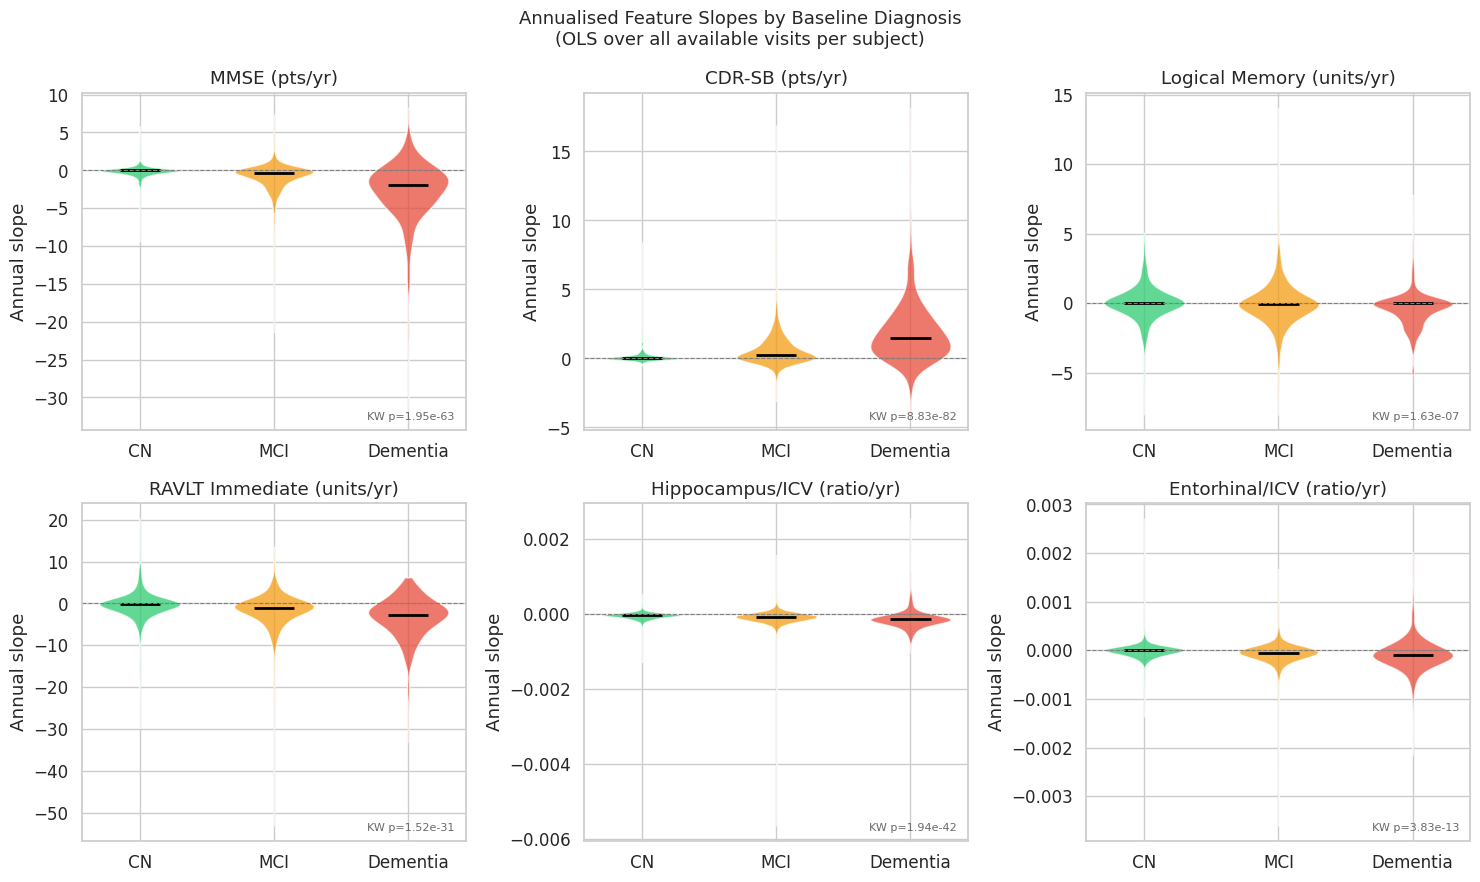

Saved: 13_slopes_by_dx.png

Slope AUROC — Stable MCI vs. MCI to Dementia:
  MMSE                : Stable=-0.0690, Conv=-1.2926 ↓  AUROC=0.799
  CDRSB               : Stable=0.0000, Conv=1.1515 ↑  AUROC=0.903
  LDELTOTAL           : Stable=0.2456, Conv=-0.5050 ↓  AUROC=0.746
  RAVLT_immediate     : Stable=-0.2795, Conv=-2.0820 ↓  AUROC=0.704
  Hippocampus_ICV     : Stable=-0.0001, Conv=-0.0001 ↓  AUROC=0.702
  Entorhinal_ICV      : Stable=-0.0000, Conv=-0.0001 ↓  AUROC=0.657


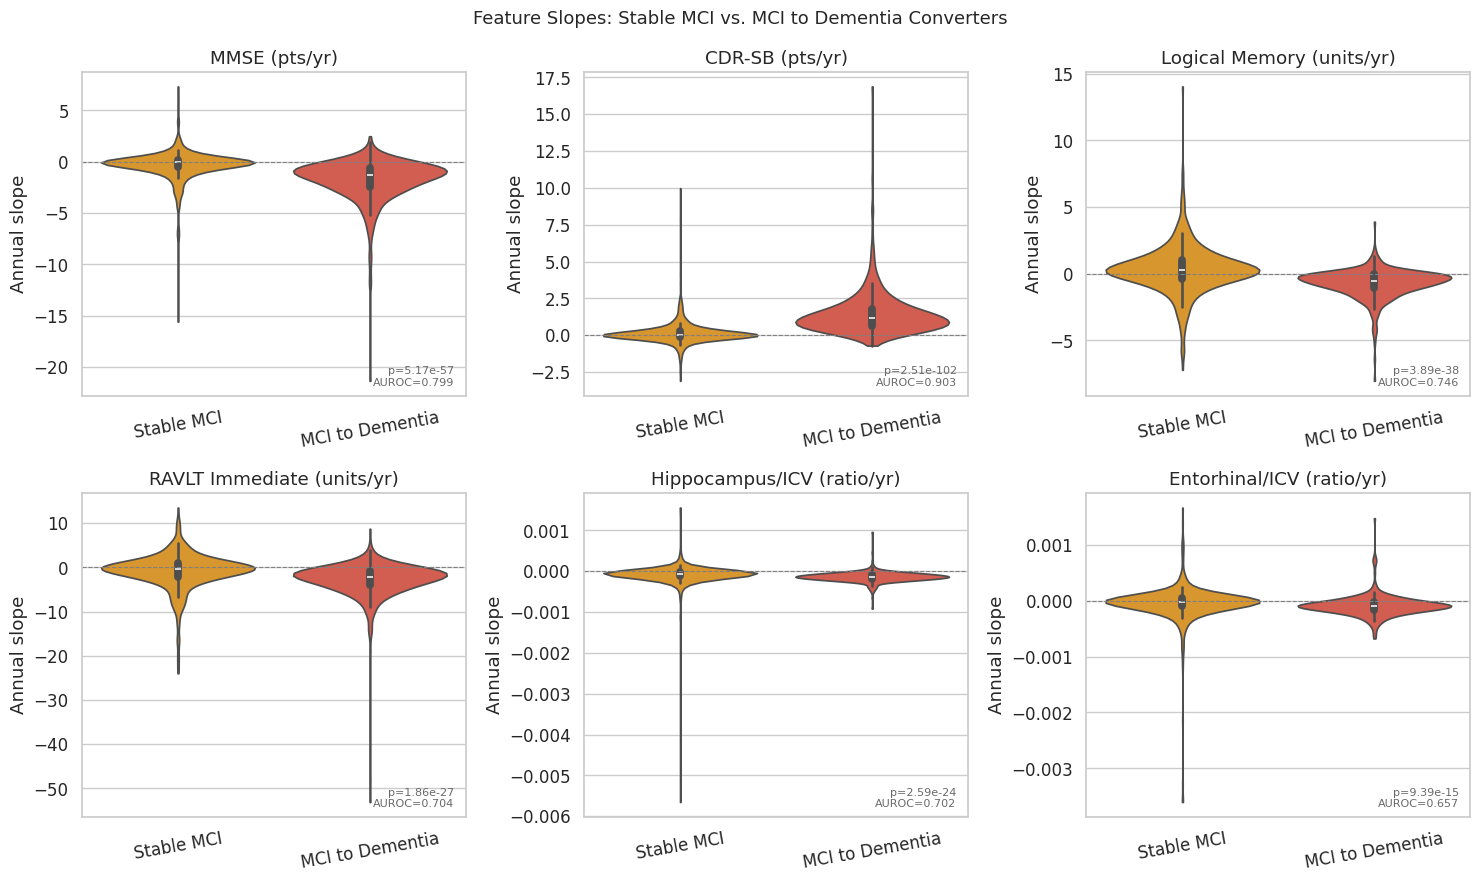

Saved: 13b_slopes_mci_conversion.png

Slope AUROC — Stable CN vs. CN to MCI:
  MMSE                : Stable=0.0000, Conv=-0.1375 ↓  AUROC=0.656
  CDRSB               : Stable=0.0000, Conv=0.1474 ↑  AUROC=0.824
  LDELTOTAL           : Stable=0.0784, Conv=-0.3145 ↓  AUROC=0.640
  RAVLT_immediate     : Stable=0.0000, Conv=-0.7413 ↓  AUROC=0.626
  Hippocampus_ICV     : Stable=-0.0000, Conv=-0.0000 ↓  AUROC=0.527
  Entorhinal_ICV      : Stable=0.0000, Conv=-0.0000 ↓  AUROC=0.586


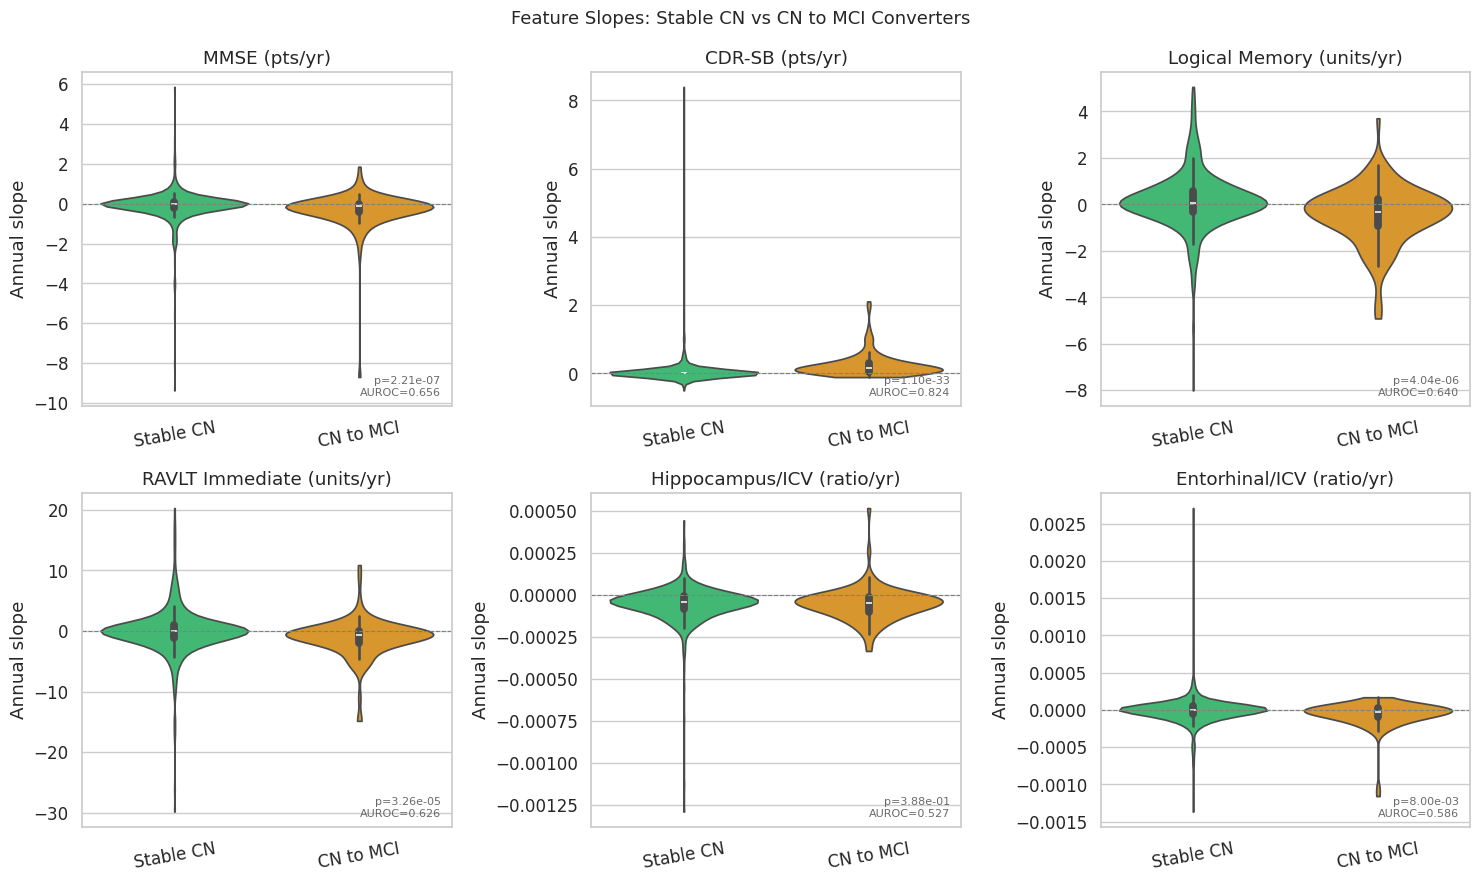

Saved: 13c_slopes_cn_mci_conversion.png

 AUROC: Baseline value vs. Slope (MCI to Dementia)
  Feature                  BL AUROC  Slope AUROC
  MMSE                        0.643        0.799   slope better
  CDRSB                       0.692        0.903   slope better
  LDELTOTAL                   0.750        0.746
  RAVLT_immediate             0.724        0.704
  Hippocampus_ICV             0.732        0.709
  Entorhinal_ICV              0.705        0.655


In [ ]:
SLOPE_FEATURES = {
    "MMSE":            "MMSE (pts/yr)",
    "CDRSB":           "CDR-SB (pts/yr)",
    "LDELTOTAL":       "Logical Memory (units/yr)",
    "RAVLT_immediate": "RAVLT Immediate (units/yr)",
    "Hippocampus_ICV": "Hippocampus/ICV (ratio/yr)",
    "Entorhinal_ICV":  "Entorhinal/ICV (ratio/yr)",
}

#ICV normalise on the full longitudinal df
df["Hippocampus_ICV"] = df["Hippocampus"] / df["ICV"]
df["Entorhinal_ICV"]  = df["Entorhinal"]  / df["ICV"]

def compute_slope(rid_df, feature, min_obs=2):
    """Per-subject OLS slope (units/year) across all available visits."""
    sub = rid_df[["Years_bl", feature]].dropna()
    if len(sub) < min_obs or sub["Years_bl"].nunique() < 2:
        return np.nan
    slope, *_ = stats.linregress(sub["Years_bl"], sub[feature])
    return slope

#compute slopes
print("Computing per-subject slopes ( about 30 s) ...")
slope_rows = []
for rid, grp in df.groupby("RID"):
    row = {"RID": rid}
    for feat in SLOPE_FEATURES:
        row[f"slope_{feat}"] = compute_slope(grp, feat)
    slope_rows.append(row)

slopes_df = (pd.DataFrame(slope_rows)
             .merge(df_bl[["RID", "DX_bl", "APOE4", "AGE"]], on="RID", how="left"))
slopes_df["mci_outcome"] = slopes_df["RID"].map(mci_conv)
slopes_df["cn_outcome"]  = slopes_df["RID"].map(cn_conv)

print(f"Done — slopes for {len(slopes_df)} subjects.")

# 13a: slope distributions by baseline DX
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (feat, label) in enumerate(SLOPE_FEATURES.items()):
    ax = axes[i]
    groups = [slopes_df[slopes_df["DX_bl"] == dx][f"slope_{feat}"].dropna()
              for dx in DX_ORDER]

    parts = ax.violinplot(groups, positions=range(3), widths=0.6,
                          showmedians=True, showextrema=False)
    for pc, dx in zip(parts["bodies"], DX_ORDER):
        pc.set_facecolor(DX_PALETTE[dx]); pc.set_alpha(0.75)
    parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(2)

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xticks(range(3)); ax.set_xticklabels(DX_ORDER)
    ax.set(title=label, ylabel="Annual slope")

    kw_p = stats.kruskal(*[g for g in groups if len(g) > 0]).pvalue
    ax.text(0.97, 0.03, f"KW p={kw_p:.2e}", transform=ax.transAxes,
            ha="right", fontsize=8, color="dimgray")

plt.suptitle("Annualised Feature Slopes by Baseline Diagnosis\n"
             "(OLS over all available visits per subject)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/13_slopes_by_dx.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 13_slopes_by_dx.png")

#13b: Stable MCI vs MCI to Dementia
mci_slopes = (slopes_df[slopes_df["DX_bl"] == "MCI"]
              .dropna(subset=["mci_outcome"])
              .query("mci_outcome in ['Stable MCI', 'MCI to Dementia']"))

PAL_MCI = {"Stable MCI": "#f39c12", "MCI to Dementia": "#e74c3c"}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

print("\nSlope AUROC — Stable MCI vs. MCI to Dementia:")
for i, (feat, label) in enumerate(SLOPE_FEATURES.items()):
    ax = axes[i]
    col = f"slope_{feat}"
    sub = mci_slopes[["mci_outcome", col]].dropna()
    stable   = sub[sub["mci_outcome"] == "Stable MCI"][col]
    convertr = sub[sub["mci_outcome"] == "MCI to Dementia"][col]

    sns.violinplot(data=sub, x="mci_outcome", y=col, ax=ax,
                   palette=PAL_MCI, inner="box", cut=0,
                   order=["Stable MCI", "MCI to Dementia"])
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set(title=label, xlabel="", ylabel="Annual slope")
    ax.tick_params(axis="x", rotation=10)

    _, p   = mannwhitneyu(stable, convertr, alternative="two-sided")
    auc    = roc_auc_score((sub["mci_outcome"] == "MCI to Dementia").astype(int), sub[col])
    auc    = max(auc, 1 - auc)
    ax.text(0.97, 0.03, f"p={p:.2e}\nAUROC={auc:.3f}",
            transform=ax.transAxes, ha="right", fontsize=8, color="dimgray")

    direction = "↑" if convertr.median() > stable.median() else "↓"
    print(f"  {feat:20s}: Stable={stable.median():.4f}, "
          f"Conv={convertr.median():.4f} {direction}  AUROC={auc:.3f}")

plt.suptitle("Feature Slopes: Stable MCI vs. MCI to Dementia Converters", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/13b_slopes_mci_conversion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 13b_slopes_mci_conversion.png")

# 13c: Stable CN vs CN to MCI
cn_slopes = (slopes_df[slopes_df["DX_bl"] == "CN"]
             .dropna(subset=["cn_outcome"])
             .query("cn_outcome in ['Stable CN', 'CN to MCI']"))

PAL_CN = {"Stable CN": "#2ecc71", "CN to MCI": "#f39c12"}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

print("\nSlope AUROC — Stable CN vs. CN to MCI:")
for i, (feat, label) in enumerate(SLOPE_FEATURES.items()):
    ax = axes[i]
    col = f"slope_{feat}"
    sub = cn_slopes[["cn_outcome", col]].dropna()
    stable   = sub[sub["cn_outcome"] == "Stable CN"][col]
    convertr = sub[sub["cn_outcome"] == "CN to MCI"][col]

    sns.violinplot(data=sub, x="cn_outcome", y=col, ax=ax,
                   palette=PAL_CN, inner="box", cut=0,
                   order=["Stable CN", "CN to MCI"])
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set(title=label, xlabel="", ylabel="Annual slope")
    ax.tick_params(axis="x", rotation=10)

    if len(stable) >= 5 and len(convertr) >= 5:
        _, p = mannwhitneyu(stable, convertr, alternative="two-sided")
        auc  = roc_auc_score((sub["cn_outcome"] == "CN to MCI").astype(int), sub[col])
        auc  = max(auc, 1 - auc)
        ax.text(0.97, 0.03, f"p={p:.2e}\nAUROC={auc:.3f}",
                transform=ax.transAxes, ha="right", fontsize=8, color="dimgray")
        direction = "↑" if convertr.median() > stable.median() else "↓"
        print(f"  {feat:20s}: Stable={stable.median():.4f}, "
              f"Conv={convertr.median():.4f} {direction}  AUROC={auc:.3f}")

plt.suptitle("Feature Slopes: Stable CN vs CN to MCI Converters", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/13c_slopes_cn_mci_conversion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 13c_slopes_cn_mci_conversion.png")

# baseline value vs slope AUROC for MCI to Dementia
print("\n AUROC: Baseline value vs. Slope (MCI to Dementia)")
mci_bl = df_bl[df_bl["DX_bl"] == "MCI"].copy()
mci_bl["Hippocampus_ICV"] = mci_bl["Hippocampus"] / mci_bl["ICV"]
mci_bl["Entorhinal_ICV"]  = mci_bl["Entorhinal"]  / mci_bl["ICV"]
mci_bl["converted"] = mci_bl["RID"].map(mci_conv) == "MCI to Dementia"
mci_bl = mci_bl.merge(slopes_df[["RID"] + [f"slope_{f}" for f in SLOPE_FEATURES]],
                       on="RID", how="left")

print(f"  {'Feature':<22} {'BL AUROC':>10} {'Slope AUROC':>12}")
for feat in SLOPE_FEATURES:
    slope_col = f"slope_{feat}"
    sub = mci_bl[["converted", feat, slope_col]].dropna()
    if len(sub) < 20:
        continue
    bl_auc = max(roc_auc_score(sub["converted"].astype(int), sub[feat]),
                 1 - roc_auc_score(sub["converted"].astype(int), sub[feat]))
    sl_auc = max(roc_auc_score(sub["converted"].astype(int), sub[slope_col]),
                 1 - roc_auc_score(sub["converted"].astype(int), sub[slope_col]))
    flag = "   slope better" if sl_auc > bl_auc else ""
    print(f"  {feat:<22} {bl_auc:>10.3f} {sl_auc:>12.3f}{flag}")

# 14a: Kaplan-Meier: MCI  to  Dementia Conversion


---


### Figure:
Three-panel Kaplan-Meier plot. Left: overall survival curve for all MCI subjects remaining unconverted. Centre: stratified by APOE4 genotype (0/1/2 alleles). Right: stratified by baseline CSF amyloid status (Aβ < 880 pg/mL = amyloid-positive vs. ≥ 880 = amyloid-negative).

### Observations:
The overall curve (left panel) shows that MCI is far from a stable state: the probability of remaining MCI drops to roughly 50% by about 4 years and continues declining through 12 years, with approximately 35% of subjects still unconverted at the end of follow-up. This is consistent with the literature — MCI carries a substantial annual conversion risk of roughly 10–15%.

The APOE4 stratification (centre panel) reveals a clear dose-response relationship. APOE4 = 0 subjects convert the slowest; APOE4 = 1 subjects convert about 1.5 years earlier; and APOE4 = 2 homozygotes convert most rapidly, crossing 50% survival well before year 4. However, the APOE4 = 2 group is small (n not large) and the curves cross somewhat at later time points, suggesting the early APOE4 effect is strong but its long-term survival advantage for non-carriers is less clear-cut.

The CSF amyloid stratification (right panel) is the most dramatic finding: amyloid-positive MCI subjects (Aβ < 880 pg/mL) convert to dementia at roughly twice the rate of amyloid-negative subjects. Their curve drops steeply to below 20% by year 12, while amyloid-negative subjects maintain  about 50% probability of remaining MCI. This confirms that CSF amyloid positivity is among the strongest available prognostic markers — but it is available for only  about 30–40% of subjects and primarily at baseline.

### Modelling Implications:

Survival analysis approaches (DeepSurv, Cox regression, time-dependent AUC) are more appropriate than simple classification for this problem, as they account for varying observation windows and right-censoring.
APOE4 and CSF Aβ should be treated as high-priority features; any model trained without them will be operating on substantially less informative data.
The large gap between amyloid+ and amyloid− curves suggests that a two-stage modelling approach — first predict amyloid status for subjects missing CSF, then use predicted amyloid status as a feature — could recover some of that predictive power.



---


# 14b: Kaplan-Meier: CN  to  Any Conversion

### Figure:
Two-panel Kaplan-Meier plot. Left: overall CN survival curve. Right: stratified by APOE4 genotype.

### Observations:
The CN to Any conversion curve (left panel) shows a far slower conversion process than MCI to Dementia. After 12 years, approximately 60% of CN subjects remain cognitively normal — meaning the event rate is modest even with long follow-up. The median conversion time does not appear to be reached within the 12-year window for the overall cohort, which has important consequences for model training: much of the CN data is right-censored (subjects are still CN at last observation).

The APOE4 stratification (right panel) shows the most striking pattern in the APOE4 = 2 group (n = 22, homozygotes): their curve drops rapidly and reaches  about 40% probability of remaining CN by year 7 — far faster than non-carriers. However, the very small APOE4 = 2 sample size means this curve is noisy and the sharp steps should be interpreted cautiously. APOE4 = 0 and APOE4 = 1 curves separate meaningfully but more gradually than in the MCI cohort, reflecting the earlier disease stage.

The juxtaposition with T2a reinforces the fundamental challenge: CN subjects have lower and slower conversion rates, making class imbalance more severe and requiring longer follow-up windows to accumulate sufficient events for model training.

### Modelling Implications:

For CN to MCI/AD prediction with a 3–5 year horizon, only a subset of the CN cohort will have had long enough follow-up to yield definitive outcome labels — careful cohort construction is required.

APOE4 = 2 homozygotes are a very high-risk subgroup but too small (n = 22) to train reliable models on independently; they should be kept in the training data but not over-weighted.

A case-control or matched design may be preferable to treating all CN subjects equally in order to address the severe class imbalance.

lifelines not found — using built-in KM (no confidence intervals).
For CIs:  pip install lifelines


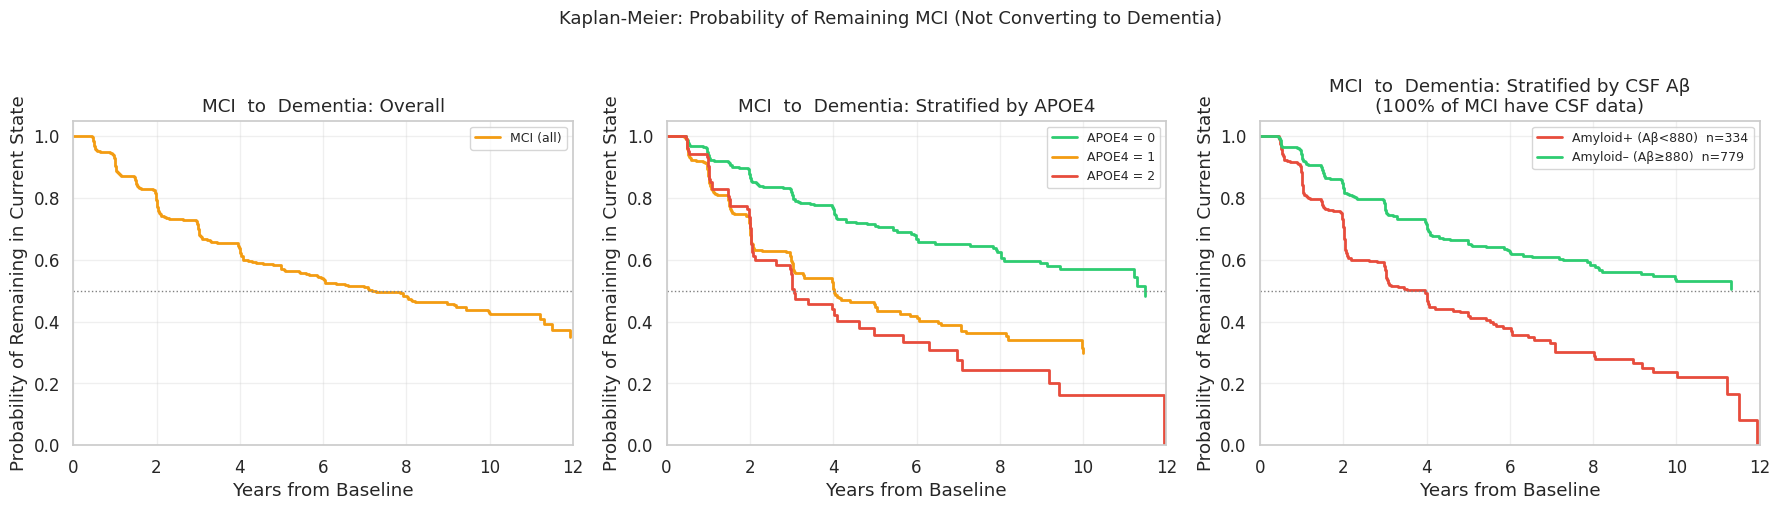

Saved: 14a_km_mci_dementia.png


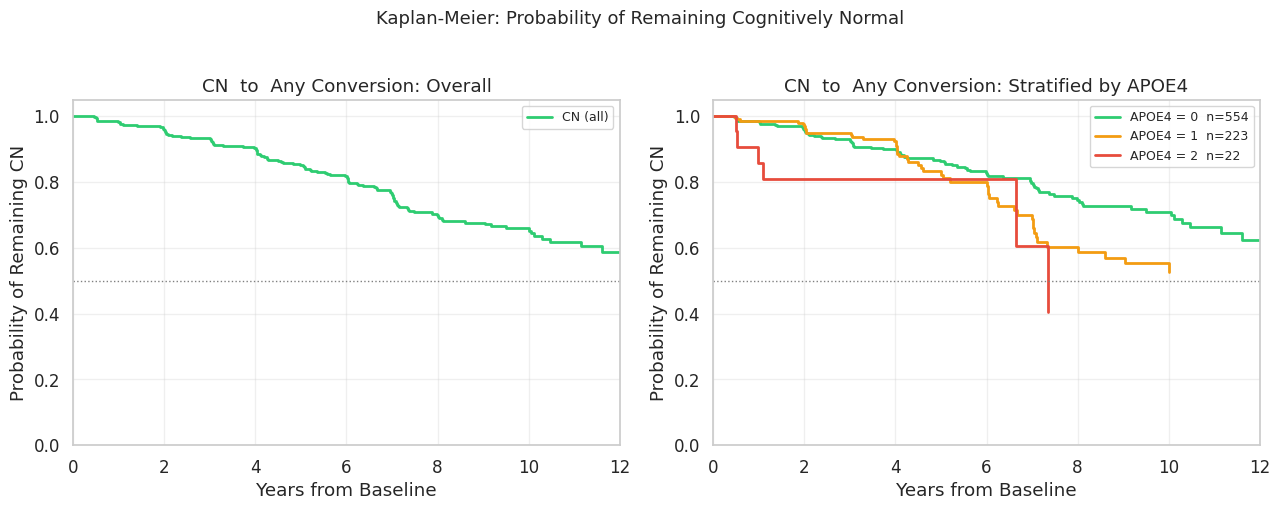

Saved: 14b_km_cn_mci.png

── Conversion summary ──
MCI  to  Dementia: 385 / 1113 (34.6%)  |  Median time: 2.0 yr
CN  to  Any:       146 / 895 (16.3%)  |  Median time: 4.1 yr


In [ ]:
#14: Kaplan Meier time to Conversion curves

try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    HAS_LIFELINES = True
    print("lifelines available.")
except ImportError:
    HAS_LIFELINES = False
    print("lifelines not found — using built-in KM (no confidence intervals).")
    print("For CIs:  pip install lifelines")

def manual_km(durations, event_observed):
    """Minimal KM estimator — returns (times, survival_probability)."""
    d = np.array(durations, dtype=float)
    e = np.array(event_observed, dtype=bool)
    order = np.argsort(d)
    d, e  = d[order], e[order]
    times, surv = [0], [1.0]
    for i, (t, ev) in enumerate(zip(d, e)):
        if ev:
            n_risk = len(d) - i
            surv.append(surv[-1] * (1 - 1 / n_risk))
            times.append(t)
    return np.array(times), np.array(surv)

def plot_km(ax, groups: dict, title: str,
            xlabel="Years from Baseline",
            ylabel="Probability of Remaining in Current State",
            max_time=12):
    for label, (durations, events, color) in groups.items():
        d = np.array(durations, dtype=float)
        e = np.array(events, dtype=bool)
        mask =  about np.isnan(d)
        d, e = d[mask], e[mask]
        if HAS_LIFELINES:
            KaplanMeierFitter().fit(d, event_observed=e, label=label).plot_survival_function(
                ax=ax, ci_show=True, color=color, at_risk_counts=False)
        else:
            t, s = manual_km(d, e)
            ax.step(t, s, where="post", label=label, color=color, linewidth=2)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel,
           xlim=(0, max_time), ylim=(0, 1.05))
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

#Build event tables
def mci_event_time(rid_df):
    dem = rid_df[(rid_df["VISCODE"] != "bl") & (rid_df["DX"] == "Dementia")].dropna(subset=["Years_bl"])
    if len(dem) > 0:
        return dem["Years_bl"].min(), True
    last = rid_df["Years_bl"].dropna()
    return (last.max() if len(last) > 0 else np.nan), False

def cn_event_time(rid_df):
    conv = rid_df[(rid_df["VISCODE"] != "bl") &
                  (rid_df["DX"].isin(["MCI", "Dementia"]))].dropna(subset=["Years_bl"])
    if len(conv) > 0:
        return conv["Years_bl"].min(), True
    last = rid_df["Years_bl"].dropna()
    return (last.max() if len(last) > 0 else np.nan), False

mci_events = (mci_long.groupby("RID")
              .apply(lambda g: pd.Series(mci_event_time(g), index=["time", "event"]))
              .reset_index()
              .merge(df_bl[df_bl["DX_bl"] == "MCI"][["RID", "APOE4", "ABETA_bl"]],
                     on="RID", how="left"))
mci_events["amyloid_pos"] = mci_events["ABETA_bl"] < 880

cn_events = (cn_long.groupby("RID")
             .apply(lambda g: pd.Series(cn_event_time(g), index=["time", "event"]))
             .reset_index()
             .merge(df_bl[df_bl["DX_bl"] == "CN"][["RID", "APOE4"]],
                    on="RID", how="left"))

#14a: MCI  to  Dementia
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_km(axes[0],
        {"MCI (all)": (mci_events["time"], mci_events["event"], "#f39c12")},
        title="MCI  to  Dementia: Overall")

apoe_groups_mci = {
    f"APOE4 = {v}": (mci_events[mci_events["APOE4"] == v]["time"],
                     mci_events[mci_events["APOE4"] == v]["event"],
                     c)
    for v, c in zip([0, 1, 2], ["#2ecc71", "#f39c12", "#e74c3c"])
}
plot_km(axes[1], apoe_groups_mci, title="MCI  to  Dementia: Stratified by APOE4")

amyloid_sub = mci_events.dropna(subset=["amyloid_pos"])
apos = amyloid_sub[amyloid_sub["amyloid_pos"]]
aneg = amyloid_sub[ about amyloid_sub["amyloid_pos"]]
pct  = len(amyloid_sub) / len(mci_events) * 100
plot_km(axes[2],
        {f"Amyloid+ (Aβ<880)  n={len(apos)}": (apos["time"], apos["event"], "#e74c3c"),
         f"Amyloid– (Aβ≥880)  n={len(aneg)}": (aneg["time"], aneg["event"], "#2ecc71")},
        title=f"MCI  to  Dementia: Stratified by CSF Aβ\n({pct:.0f}% of MCI have CSF data)")

if HAS_LIFELINES:
    carriers = pd.concat([mci_events[mci_events["APOE4"] == v] for v in [1, 2]])
    non_carr = mci_events[mci_events["APOE4"] == 0]
    lr = logrank_test(non_carr["time"], carriers["time"],
                      event_observed_A=non_carr["event"],
                      event_observed_B=carriers["event"])
    axes[1].text(0.02, 0.05, f"Log-rank p={lr.p_value:.3e}",
                 transform=axes[1].transAxes, fontsize=9)

plt.suptitle("Kaplan-Meier: Probability of Remaining MCI (Not Converting to Dementia)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/14a_km_mci_dementia.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 14a_km_mci_dementia.png")

# 14b: CN  to  Any Conversion
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_km(axes[0],
        {"CN (all)": (cn_events["time"], cn_events["event"], "#2ecc71")},
        title="CN  to  Any Conversion: Overall",
        ylabel="Probability of Remaining CN")

apoe_groups_cn = {
    f"APOE4 = {v}  n={len(cn_events[cn_events['APOE4']==v])}": (
        cn_events[cn_events["APOE4"] == v]["time"],
        cn_events[cn_events["APOE4"] == v]["event"], c)
    for v, c in zip([0, 1, 2], ["#2ecc71", "#f39c12", "#e74c3c"])
}
plot_km(axes[1], apoe_groups_cn,
        title="CN  to  Any Conversion: Stratified by APOE4",
        ylabel="Probability of Remaining CN")

plt.suptitle("Kaplan-Meier: Probability of Remaining Cognitively Normal",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/14b_km_cn_mci.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 14b_km_cn_mci.png")

# Summary stats
print(f"\n── Conversion summary ──")
print(f"MCI  to  Dementia: {int(mci_events['event'].sum())} / {len(mci_events)} "
      f"({mci_events['event'].mean()*100:.1f}%)  |  "
      f"Median time: {mci_events[mci_events['event']]['time'].median():.1f} yr")
print(f"CN  to  Any:       {int(cn_events['event'].sum())} / {len(cn_events)} "
      f"({cn_events['event'].mean()*100:.1f}%)  |  "
      f"Median time: {cn_events[cn_events['event']]['time'].median():.1f} yr")

# 15a: Baseline Data Availability: Subject × Modality Heatmap

### Figure:
Binary heatmap where each row is a subject and each column is a data modality. Green = data available, red = missing. Subjects are grouped by baseline diagnosis (CN / MCI / Dementia) and sorted within each group by completeness.

### Observations:
The heatmap makes the block-wise missingness structure immediately apparent — this is not random missingness. There are clearly defined subject subsets who have all neuroimaging data (cognitive + MRI + PET + CSF) and other subsets who have only cognitive assessments. Within each DX group, the missing data clusters into rows, reflecting cohort-level collection decisions rather than individual data quality issues.

The most complete modalities — cognitive battery (MMSE, CDR-SB, Logical Memory) — show near-100% availability, represented by solid green columns on the left. The MRI columns (Hippocampus, Entorhinal, Ventricles) are mostly green with scattered missing rows, indicating  about 85% availability at baseline. The PET columns tell a completely different story: FDG-PET is available for  about 62% at baseline, AV45 (amyloid PET) for  about 47%, and FBB (tau PET) for only  about 14%, with large red blocks showing systematic absence for many subjects.
CSF Aβ and CSF Tau (both  about 50% at baseline) show a similar pattern of block-wise missingness — entire subject subgroups either had lumbar puncture or did not, with no partial data. APOE4 is extremely complete ( about 91%) and shows only isolated missing values.

Comparing the three DX groups visually, the MCI group appears to have proportionally higher PET and CSF coverage than CN, reflecting the study design — more invasive procedures were prioritised in higher-risk subjects.

### Modelling Implications:

Missingness is non-random and correlated with subject characteristics (DX, protocol phase, site). Any imputation strategy must account for this; mean or median imputation would introduce substantial bias.

The modal data availability pattern for a typical subject is: cognitive (100%) + MRI (85%) + APOE4 (91%) + optionally PET/CSF ( about 40–50%). Models should be designed to work well with this core set and treat PET/CSF as supplementary.
Missing data pattern itself may be informative — whether a subject had a lumbar puncture may correlate with clinician suspicion of disease, which could introduce leakage if the missing indicator is used naively.



---


# 15b: Modality Availability Over Time

### Figure:
Line plot showing the percentage of subjects with valid data at each visit code (BL through M120) for six key modalities: MMSE, Hippocampus (MRI), FDG-PET, AV45-PET, CSF Aβ, and APOE4.

### Observations:
APOE4 is collected once and then effectively 100% available at all future visits — a static genetic variable that never needs re-measurement. MMSE maintains approximately 80–95% coverage through M72 before declining to  about 65–75% at M108–M120, reflecting study attrition.

Hippocampus (MRI) coverage oscillates between 60–85% at most standard visits, with striking valleys at M18 ( about 19%) and M36 ( about 40%) — these odd-year visits are not standard imaging time points in all ADNI phases, so far fewer subjects were imaged at these intervals. This is critical for longitudinal modelling: MRI is essentially bi-annual in practice, not annual.

The most dramatic finding is in the PET and CSF lines. CSF Aβ drops from 50% at baseline to effectively 0% at M06, recovers partially to  about 28% at M24, then stays below 10% at all subsequent visits. FDG-PET is similar: 62% at baseline, falling to  about 20% at M06 and oscillating between 15–40% thereafter. AV45-PET shows an unusual pattern with essentially 0% at early visits (M06–M18) then recovering to 40–47% at M24 and M48 — this reflects the introduction of amyloid PET to the ADNI protocol in later phases.

### Modelling Implications:

Any model requiring CSF as a longitudinal input feature is essentially limited to baseline data for CSF variables — the follow-up availability is too low to build reliable trajectories.

The bi-annual MRI schedule means per-subject MRI slope estimates will have fewer data points than cognitive slopes (which are collected at every visit).
The visit-level completeness pattern should inform how training examples are constructed — for example, a model predicting 2-year conversion from M24 data has very different feature availability than one predicting from baseline data.

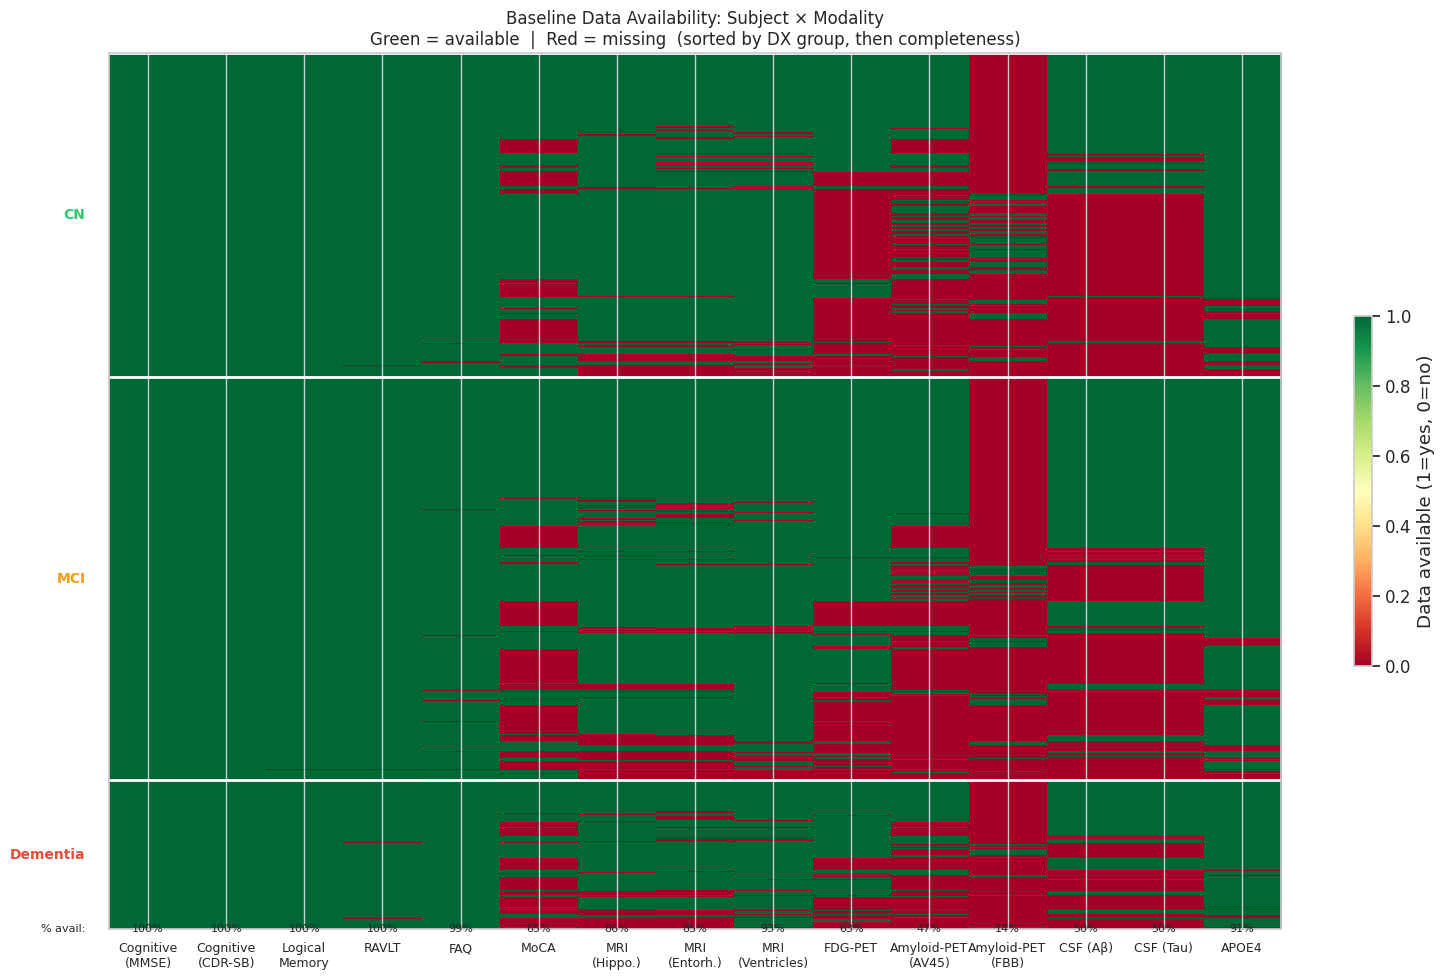

Saved: 15a_modality_heatmap.png

── Joint modality coverage at baseline ──
  Cogn + MRI                         : 1958 subjects  (80.9%)
  Cogn + MRI + APOE4                 : 1819 subjects  (75.2%)
  Cogn + MRI + CSF                   :  972 subjects  (40.2%)
  Cogn + MRI + PET                   : 1561 subjects  (64.5%)
  Cogn + MRI + CSF + PET             :  809 subjects  (33.4%)
  All modalities                     :  809 subjects  (33.4%)


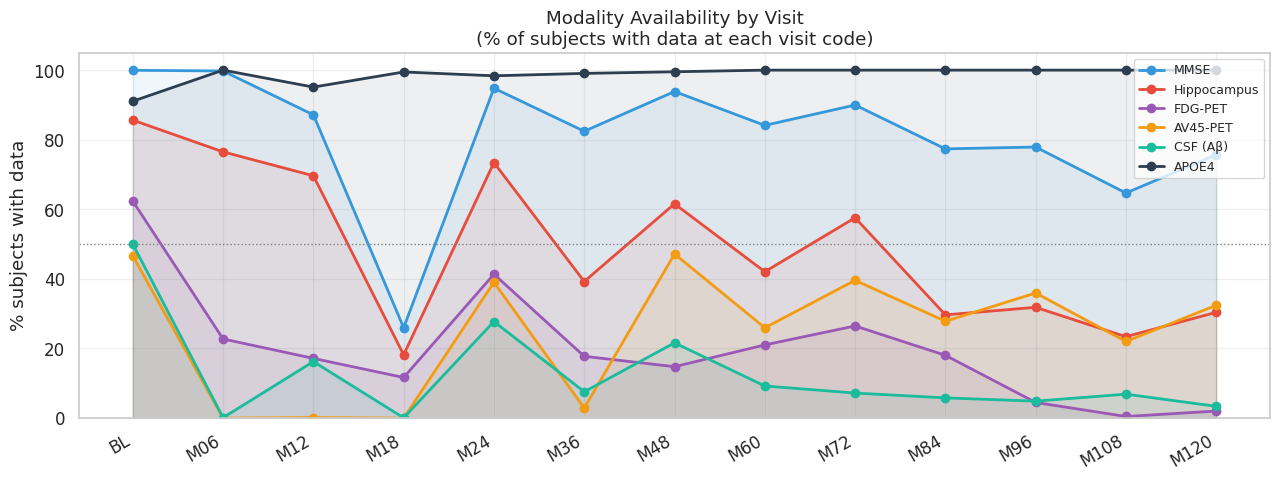

Saved: 15b_modality_over_time.png


In [ ]:
#15: multimodal data availability matrix
MODALITIES = {
    "Cognitive\n(MMSE)":   ["MMSE"],
    "Cognitive\n(CDR-SB)": ["CDRSB"],
    "Logical\nMemory":     ["LDELTOTAL"],
    "RAVLT":               ["RAVLT_immediate"],
    "FAQ":                 ["FAQ"],
    "MoCA":                ["MOCA"],
    "MRI\n(Hippo.)":       ["Hippocampus"],
    "MRI\n(Entorh.)":      ["Entorhinal"],
    "MRI\n(Ventricles)":   ["Ventricles"],
    "FDG-PET":             ["FDG"],
    "Amyloid-PET\n(AV45)": ["AV45"],
    "Amyloid-PET\n(FBB)":  ["FBB"],
    "CSF (Aβ)":            ["ABETA"],
    "CSF (Tau)":           ["TAU"],
    "APOE4":               ["APOE4"],
}

bl_avail = df_bl[df_bl["DX_bl"].isin(DX_ORDER)].copy()

mod_matrix = pd.DataFrame({"RID": bl_avail["RID"].values,
                            "DX_bl": bl_avail["DX_bl"].values})
for mod_name, cols in MODALITIES.items():
    valid = [c for c in cols if c in bl_avail.columns]
    mod_matrix[mod_name] = bl_avail[valid].notna().any(axis=1).astype(int).values

dx_sort = {"CN": 0, "MCI": 1, "Dementia": 2}
mod_matrix["_dx_key"]      = mod_matrix["DX_bl"].map(dx_sort)
mod_matrix["_completeness"] = mod_matrix[list(MODALITIES.keys())].sum(axis=1)
mod_matrix = mod_matrix.sort_values(["_dx_key", "_completeness"],
                                     ascending=[True, False]).reset_index(drop=True)

# 15a: subject by modality heatmap
fig, ax = plt.subplots(figsize=(16, 10))
heat = mod_matrix[list(MODALITIES.keys())].values.astype(float)
im   = ax.imshow(heat, aspect="auto", cmap=plt.cm.RdYlGn,
                 vmin=0, vmax=1, interpolation="nearest")

ax.set_xticks(range(len(MODALITIES)))
ax.set_xticklabels(list(MODALITIES.keys()), fontsize=9)
ax.set_yticks([])
ax.set_title("Baseline Data Availability: Subject × Modality\n"
             "Green = available  |  Red = missing  "
             "(sorted by DX group, then completeness)", fontsize=12)

boundaries = [0]
for _, grp in mod_matrix.groupby("_dx_key", sort=True):
    boundaries.append(boundaries[-1] + len(grp))
for start, end, label in zip(boundaries[:-1], boundaries[1:], DX_ORDER):
    ax.axhline(start - 0.5, color="white", linewidth=2)
    ax.text(-0.8, (start + end) / 2, label, va="center", ha="right",
            fontsize=10, color=DX_PALETTE[label], fontweight="bold")

for j, mod in enumerate(MODALITIES.keys()):
    pct = mod_matrix[mod].mean() * 100
    ax.text(j, len(mod_matrix) + 8, f"{pct:.0f}%", ha="center", fontsize=8)
ax.text(-0.8, len(mod_matrix) + 8, "% avail:", ha="right", fontsize=8)

plt.colorbar(im, ax=ax, shrink=0.4, label="Data available (1=yes, 0=no)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/15a_modality_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 15a_modality_heatmap.png")

# Joint availability summary
mod_matrix["has_cogn"] = mod_matrix[["Cognitive\n(MMSE)", "Logical\nMemory", "FAQ"]].all(axis=1)
mod_matrix["has_mri"]  = mod_matrix[["MRI\n(Hippo.)", "MRI\n(Entorh.)"]].all(axis=1)
mod_matrix["has_csf"]  = mod_matrix[["CSF (Aβ)", "CSF (Tau)"]].all(axis=1)
mod_matrix["has_pet"]  = mod_matrix[["FDG-PET", "Amyloid-PET\n(AV45)", "Amyloid-PET\n(FBB)"]].any(axis=1)
mod_matrix["has_gene"] = mod_matrix["APOE4"].astype(bool)

combos = {
    "Cogn + MRI":             ["has_cogn", "has_mri"],
    "Cogn + MRI + APOE4":    ["has_cogn", "has_mri", "has_gene"],
    "Cogn + MRI + CSF":      ["has_cogn", "has_mri", "has_csf"],
    "Cogn + MRI + PET":      ["has_cogn", "has_mri", "has_pet"],
    "Cogn + MRI + CSF + PET":["has_cogn", "has_mri", "has_csf", "has_pet"],
    "All modalities":         ["has_cogn", "has_mri", "has_csf", "has_pet", "has_gene"],
}
print("\n── Joint modality coverage at baseline ──")
for name, cols in combos.items():
    n   = mod_matrix[cols].all(axis=1).sum()
    pct = n / len(mod_matrix) * 100
    print(f"  {name:<35}: {n:4d} subjects  ({pct:.1f}%)")

# 15b: availability over visit time
VISIT_ORDER = ["bl","m06","m12","m18","m24","m36","m48",
               "m60","m72","m84","m96","m108","m120"]

MODALITIES_LONG = {
    "MMSE":        ["MMSE"],
    "Hippocampus": ["Hippocampus"],
    "FDG-PET":     ["FDG"],
    "AV45-PET":    ["AV45"],
    "CSF (Aβ)":    ["ABETA"],
    "APOE4":       ["APOE4"],
}
df_visits = df[df["VISCODE"].isin(VISIT_ORDER)].copy()

avail_time = {
    mod: df_visits.groupby("VISCODE")[cols].apply(
        lambda x: x.notna().any(axis=1).mean() * 100
    ).reindex(VISIT_ORDER)
    for mod, cols in MODALITIES_LONG.items()
    if all(c in df_visits.columns for c in cols)
}

fig, ax = plt.subplots(figsize=(13, 5))
colors = ["#3498db", "#e74c3c", "#9b59b6", "#f39c12", "#1abc9c", "#2c3e50"]
for (mod, series), color in zip(avail_time.items(), colors):
    ax.plot(VISIT_ORDER, series.values, marker="o", label=mod,
            color=color, linewidth=2, markersize=6)
    ax.fill_between(range(len(VISIT_ORDER)), series.values, alpha=0.08, color=color)

ax.set_xticks(range(len(VISIT_ORDER)))
ax.set_xticklabels([v.replace("m", "M").replace("bl", "BL") for v in VISIT_ORDER],
                   rotation=30, ha="right")
ax.set(title="Modality Availability by Visit\n"
             "(% of subjects with data at each visit code)",
       ylabel="% subjects with data", ylim=(0, 105))
ax.axhline(50, color="gray", linestyle=":", linewidth=1)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/15b_modality_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 15b_modality_over_time.png")





# 16a: APOE4 × Biomarker Interactions Within Diagnosis Groups

### Figure:
4-row × 3-column grid of boxplots. Rows: Hippocampus/ICV, CSF Amyloid-β, CSF p-Tau, MMSE. Columns: CN, MCI, Dementia. Within each panel, boxes show the distribution for APOE4 = 0, 1, and 2 subjects. Kruskal-Wallis p-values annotated per panel.

### Observations:
Hippocampus/ICV (Row 1): The APOE4 effect on hippocampal volume is surprisingly weak within diagnosis groups. In CN subjects, the KW p-value is 0.33 (non-significant), meaning APOE4 carriers do not have detectably smaller hippocampi than non-carriers when they are still cognitively normal. In MCI the effect becomes borderline significant (p = 1.7×10⁻³), and in Dementia it again fails significance (p = 0.12). The effect sizes are tiny — at most a few percent difference in median volume. This suggests APOE4 does not directly accelerate hippocampal atrophy independently of clinical progression; its risk effect is channelled primarily through amyloid accumulation.

CSF Amyloid-β (Row 2): This is where the APOE4 effect is dramatic and unmistakable. Even within the CN group, APOE4 dosage strongly predicts amyloid burden: APOE4 = 0 subjects have a median Aβ of  about 1398 pg/mL (low amyloid), APOE4 = 1 median is  about 878 pg/mL, and APOE4 = 2 median drops to  about 600 pg/mL — less than half the non-carrier value (KW p = 1.6×10⁻¹⁰). This confirms that APOE4 acts primarily by promoting amyloid accumulation, even decades before clinical symptoms appear. The same pattern intensifies across MCI and Dementia groups. Notably, even APOE4 = 0 Dementia subjects have substantially depleted Aβ ( about 750 pg/mL median), consistent with the presence of amyloid pathology in APOE4-independent AD.

CSF p-Tau (Row 3): The p-Tau picture is more complex. In CN subjects, APOE4 = 1 carriers show slightly elevated p-Tau relative to non-carriers (KW p = 6.9×10⁻⁴), but APOE4 = 2 homozygotes paradoxically show lower p-Tau medians — likely a sample size artifact (n = 9 in this cell). In MCI, the APOE4 dose-response for p-Tau is clear and significant (p = 3.6×10⁻¹⁸): higher APOE4 load  to  higher p-Tau  to  more tau pathology and neurodegeneration.
MMSE (Row 4): MMSE is essentially flat across APOE4 groups within each DX group (all p-values non-significant or borderline). This makes sense — MMSE captures current cognitive state, which is already captured by the diagnosis grouping. APOE4 affects the probability of being in a given group, not the severity within a group.

### Modelling Implications:

APOE4 is most informative as a predictor of amyloid burden and conversion risk, not as a direct predictor of cognitive severity or hippocampal volume at a single time point.

When building a model, APOE4 × CSF Aβ interaction terms (or a product feature) may capture the non-linear gene-biomarker relationship more effectively than either feature alone.

The weak within-group hippocampal volume effect of APOE4 suggests that including both APOE4 and hippocampal volume as independent features is appropriate — they are not redundant.



---


# 16b: Hippocampus/ICV Heatmap by Diagnosis × APOE4 Genotype

### Figure:
3×3 heatmap (Diagnosis × APOE4 genotype) showing median Hippocampus/ICV. Green = larger (healthier) hippocampus, red = smaller (more atrophy).

### Observations:
The heatmap cleanly visualises the dominant effect of diagnosis versus the modest effect of APOE4 on hippocampal volume. Reading down each column (same APOE4, increasing disease severity): CN (0.0050)  to  MCI (0.0046)  to  Dementia (0.0038) — a  about 24% reduction from CN to Dementia that is highly consistent across all APOE4 groups. The colour gradient from green (CN row) to red (Dementia row) visually confirms that diagnosis drives hippocampal atrophy far more than genotype.

Reading across each row (same diagnosis, increasing APOE4 dosage): in CN, the values are 0.0050, 0.0051, 0.0051 — essentially identical. In MCI, 0.0046, 0.0044, 0.0043 — a small, consistent decline. In Dementia, 0.0038, 0.0037, 0.0038 — again minimal difference. The APOE4 effect on hippocampal volume, while present in MCI, is small relative to the overall diagnosis effect.
The sample size annotations are important: the APOE4 = 2 CN cell has only n = 17, making its estimate unreliable. All Dementia APOE4 groups are modestly sized (n = 65–159).

### Modelling Implications:

This plot justifies treating diagnosis stage and hippocampal volume as the primary structural signal, with APOE4 as a secondary modifier.

For cross-sectional baseline models, the 3×3 cell medians here can serve as prior expectations for sanity-checking model predictions.

APOE4 × Feature — median values by DX and APOE4:
  CN       Hippocampus_ICV     : APOE0=0.004998  APOE1=0.005148  APOE2=0.005129
  MCI      Hippocampus_ICV     : APOE0=0.004583  APOE1=0.004438  APOE2=0.004266
  Dementia Hippocampus_ICV     : APOE0=0.003838  APOE1=0.003673  APOE2=0.003789
  CN       ABETA               : APOE0=1398  APOE1=877.5  APOE2=600.2
  MCI      ABETA               : APOE0=1098  APOE1=723.4  APOE2=561
  Dementia ABETA               : APOE0=749.9  APOE1=593.9  APOE2=458.3
  CN       PTAU                : APOE0=18.57  APOE1=21.9  APOE2=20.71
  MCI      PTAU                : APOE0=19.88  APOE1=28.99  APOE2=29.37
  Dementia PTAU                : APOE0=30.62  APOE1=33.6  APOE2=36.69
  CN       MMSE                : APOE0=29  APOE1=29  APOE2=29
  MCI      MMSE                : APOE0=28  APOE1=28  APOE2=28
  Dementia MMSE                : APOE0=23  APOE1=23  APOE2=23


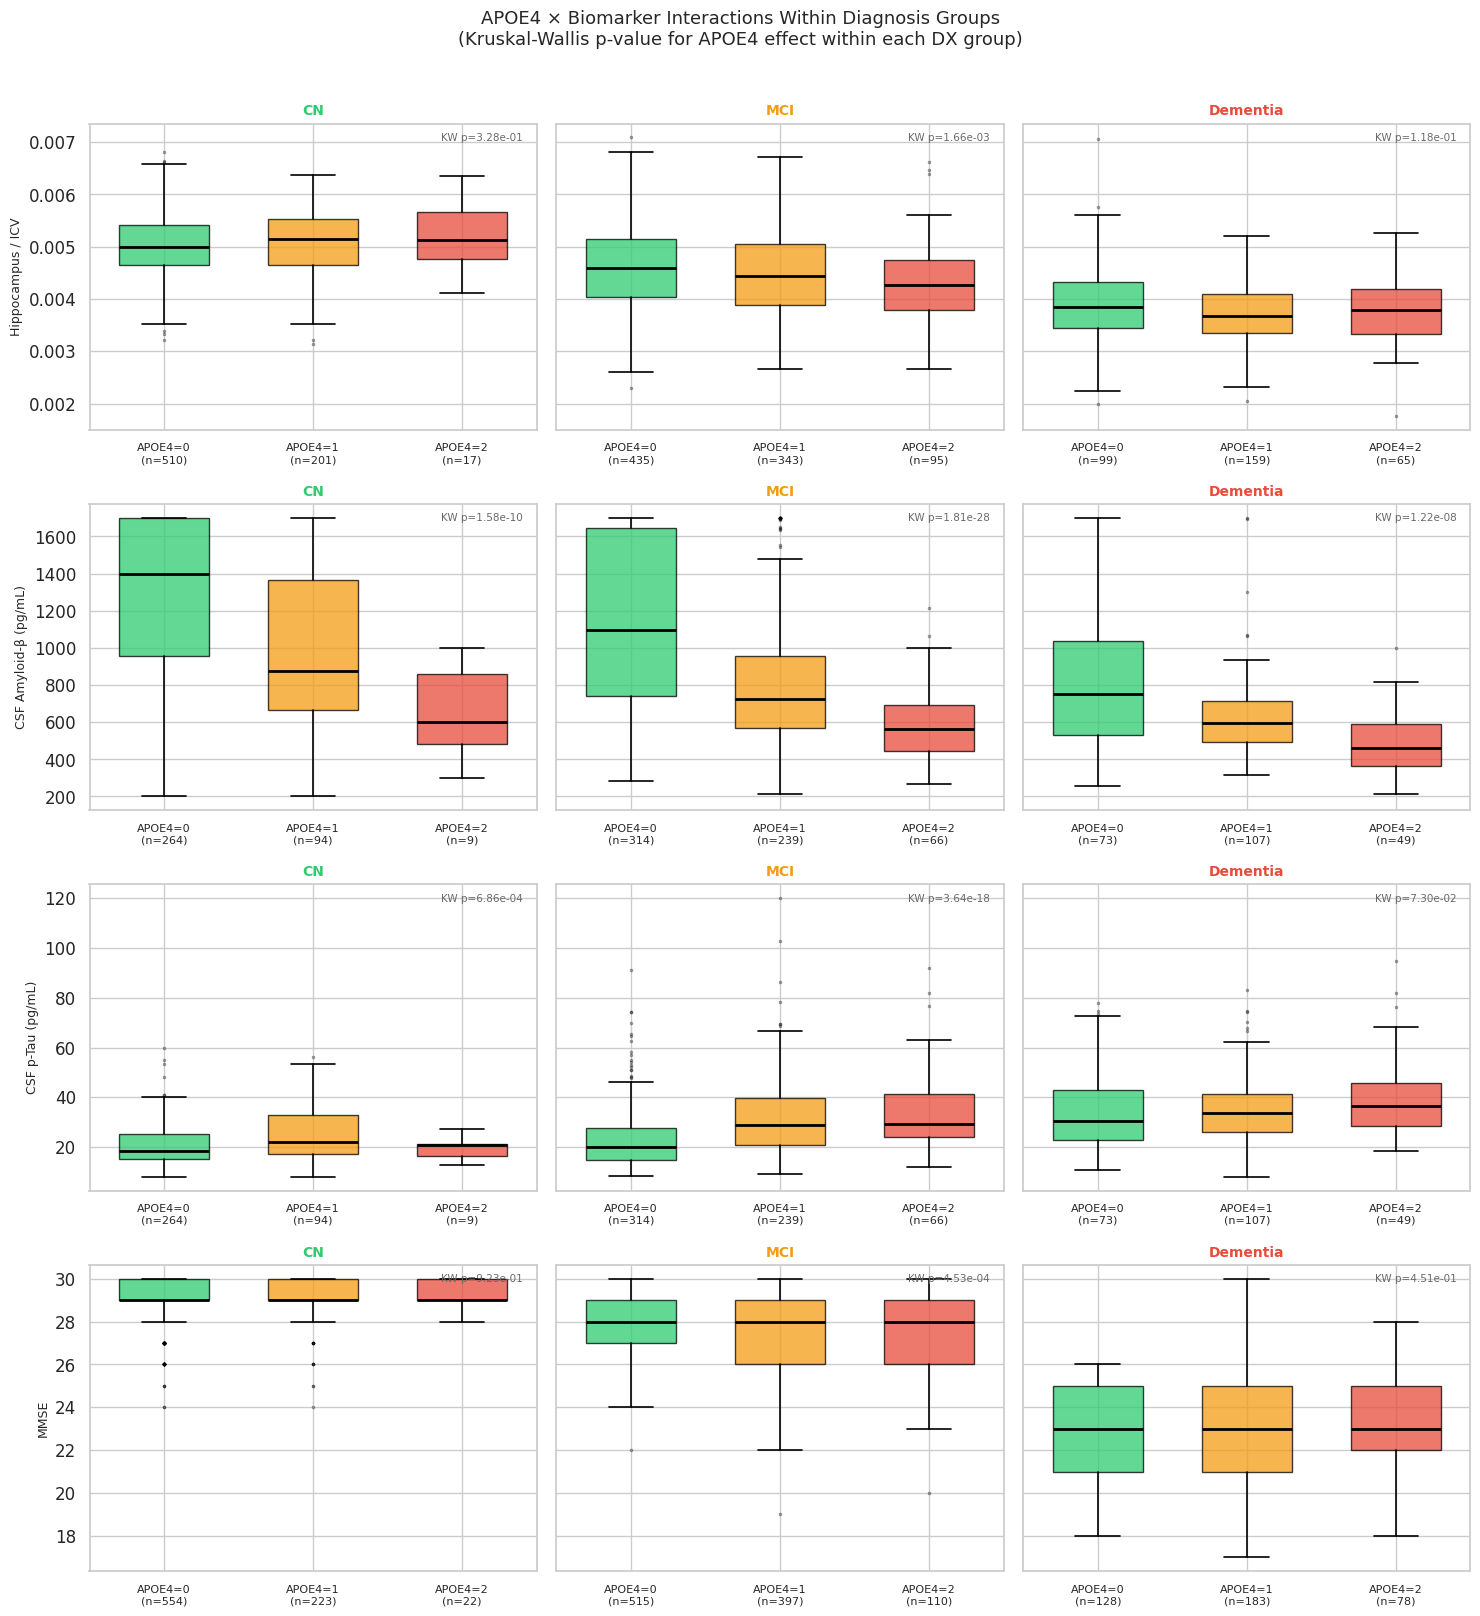


Saved: 16a_apoe4_interaction.png


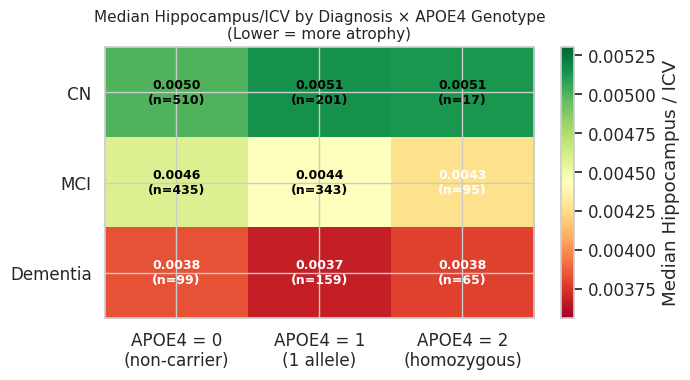

Saved: 16b_apoe4_heatmap.png


In [ ]:

# APOE4 × feature interaction plots


df_bl["Hippocampus_ICV"] = df_bl["Hippocampus"] / df_bl["ICV"]
df_bl["Entorhinal_ICV"]  = df_bl["Entorhinal"]  / df_bl["ICV"]

APOE_PAL   = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}
APOE_LABEL = {0: "APOE4 = 0\n(non-carrier)", 1: "APOE4 = 1\n(1 allele)", 2: "APOE4 = 2\n(homozygous)"}

INTERACTION_FEATURES = {
    "Hippocampus_ICV": "Hippocampus / ICV",
    "ABETA":           "CSF Amyloid-β (pg/mL)",
    "PTAU":            "CSF p-Tau (pg/mL)",
    "MMSE":            "MMSE",
}

# 16a: Boxplots: within DX split by APOE4
n_feats = len(INTERACTION_FEATURES)
fig, axes = plt.subplots(n_feats, 3, figsize=(15, 4 * n_feats), sharey="row")

print("APOE4 × Feature — median values by DX and APOE4:")
for row_i, (feat, feat_label) in enumerate(INTERACTION_FEATURES.items()):
    for col_i, dx in enumerate(DX_ORDER):
        ax = axes[row_i, col_i]
        sub = df_bl[(df_bl["DX_bl"] == dx) & df_bl["APOE4"].notna() &
                    df_bl[feat].notna()].copy()
        sub["APOE4"] = sub["APOE4"].astype(int)

        groups = [sub[sub["APOE4"] == a][feat].values for a in [0, 1, 2]]
        n_per  = [len(g) for g in groups]

        bp = ax.boxplot(
            [g for g in groups if len(g) > 0],
            positions=[a for a, g in zip([0, 1, 2], groups) if len(g) > 0],
            patch_artist=True, widths=0.6,
            medianprops=dict(color="black", linewidth=2),
            flierprops=dict(marker=".", markersize=3, alpha=0.4),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2)
        )
        for patch, apoe in zip(bp["boxes"],
                               [a for a in [0, 1, 2] if len(groups[a]) > 0]):
            patch.set_facecolor(APOE_PAL[apoe]); patch.set_alpha(0.75)

        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels([f"APOE4={a}\n(n={n_per[a]})" for a in [0, 1, 2]], fontsize=8)
        ax.set_title(f"{dx}", fontsize=10,
                     color=DX_PALETTE[dx], fontweight="bold")
        if col_i == 0:
            ax.set_ylabel(feat_label, fontsize=9)

        # Kruskal Wallis across APOE4 groups within this DX
        valid = [g for g in groups if len(g) >= 3]
        if len(valid) >= 2:
            kw_p = stats.kruskal(*valid).pvalue
            ax.text(0.97, 0.97, f"KW p={kw_p:.2e}",
                    transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
                    color="dimgray")

        # print medians
        medians = [np.median(g) if len(g) > 0 else np.nan for g in groups]
        print(f"  {dx:8s} {feat:20s}: "
              f"APOE0={medians[0]:.4g}  APOE1={medians[1]:.4g}  APOE2={medians[2]:.4g}")

plt.suptitle("APOE4 × Biomarker Interactions Within Diagnosis Groups\n"
             "(Kruskal-Wallis p-value for APOE4 effect within each DX group)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/16a_apoe4_interaction.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: 16a_apoe4_interaction.png")

# 16b: heatmap of median hippocampus/ICV by DX × APOE4
pivot = (df_bl.dropna(subset=["APOE4", "Hippocampus_ICV", "DX_bl"])
         .assign(APOE4=lambda x: x["APOE4"].astype(int))
         .groupby(["DX_bl", "APOE4"])["Hippocampus_ICV"]
         .median()
         .unstack("APOE4")
         .reindex(DX_ORDER))

# also compute n for annotation
pivot_n = (df_bl.dropna(subset=["APOE4", "Hippocampus_ICV", "DX_bl"])
           .assign(APOE4=lambda x: x["APOE4"].astype(int))
           .groupby(["DX_bl", "APOE4"])["Hippocampus_ICV"]
           .count()
           .unstack("APOE4")
           .reindex(DX_ORDER))

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto",
               vmin=pivot.values.min() * 0.97,
               vmax=pivot.values.max() * 1.03)

ax.set_xticks(range(3))
ax.set_xticklabels(["APOE4 = 0\n(non-carrier)", "APOE4 = 1\n(1 allele)",
                    "APOE4 = 2\n(homozygous)"])
ax.set_yticks(range(3))
ax.set_yticklabels(DX_ORDER)

for i in range(3):
    for j in range(3):
        val = pivot.values[i, j]
        n   = pivot_n.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.4f}\n(n={int(n)})",
                    ha="center", va="center", fontsize=9, fontweight="bold",
                    color="black" if val > pivot.values.mean() else "white")

plt.colorbar(im, ax=ax, label="Median Hippocampus / ICV")
ax.set_title("Median Hippocampus/ICV by Diagnosis × APOE4 Genotype\n"
             "(Lower = more atrophy)", fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/16b_apoe4_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 16b_apoe4_heatmap.png")







# 17: Scanner / Protocol Batch Effect Analysis

### Figure:
Three-panel figure. Left: violin plots of Hippocampus/ICV by protocol (ADNI1, ADNIGO, ADNI2, ADNI3). Centre: scatter plot of within-subject Hippocampus/ICV jump at the ADNI1 to ADNI2 transition (n = 170 subjects). Right: bar chart of median Hippocampus/ICV by field strength (1.5T vs. 3T) × DX.

### Observations:
Left panel: There is a clear and statistically significant difference in median Hippocampus/ICV across protocols (KW p ≈ 2×10⁻²²⁴). ADNI1 has the lowest median (0.0041), followed by ADNIGO (0.0047), ADNI2 (0.0046), and ADNI3 (0.0049). The jump from ADNI1 (predominantly 1.5T scanners) to ADNI2/3 (predominantly 3T scanners) is immediately visible. This is not biology — 3T scanners have higher resolution and yield systematically different FreeSurfer segmentation volumes than 1.5T.

Centre panel: The within-subject analysis is the most rigorous test. For 170 subjects who appear in both ADNI1 and ADNI2, the median jump in Hippocampus/ICV at the protocol transition is −0.0001 (small but not zero), and the one-sample t-test confirms the deviation from zero is highly significant (p = 6.8×10⁻¹¹). The scatter is large — individual subjects show jumps ranging from −0.0008 to +0.0004 — but the systematic negative bias (ADNI2 tends to measure slightly lower Hippocampus/ICV than ADNI1 for the same brain) is real. This is a genuine batch effect.

Right panel: Field strength directly explains much of the protocol difference. 3T scanners consistently measure higher Hippocampus/ICV than 1.5T scanners within each DX group. The gap is most visible in CN subjects ( about 0.0046 for 1.5T vs.  about 0.0050 for 3T), representing a  about 9% systematic difference.

### Modelling Implications:

This is a critical finding for model validity. Any model trained on ADNI1 data and tested on ADNI2/3 data (or vice versa) will experience spurious hippocampal volume shifts that are not biologically meaningful.

Standard mitigation approaches include: (1) including COLPROT or FLDSTRENG as a covariate in all models; (2) applying ComBat harmonization to MRI-derived features before modelling; or (3) restricting analysis to a single protocol phase.

For longitudinal models, subjects who transition between protocols mid-study should have their MRI trajectories examined carefully — a spurious "improvement" in hippocampal volume at the transition will corrupt their atrophy slope.


Within-subject ADNI1 to ADNI2 transitions: 170
  Median Hippocampus/ICV jump at transition: -0.00010
  (positive = apparent increase at transition; expected biological change ≈ -0.00011)
  One-sample t-test vs. 0: p=6.7731e-11

Field strength × DX median Hippocampus/ICV:
  CN       1.5 T: median=0.00464  n=1039
  MCI      1.5 T: median=0.00386  n=1627
  Dementia 1.5 T: median=0.00345  n=462
  CN       3 T : median=0.00495  n=1097
  MCI      3 T : median=0.00463  n=1970
  Dementia 3 T : median=0.00381  n=379


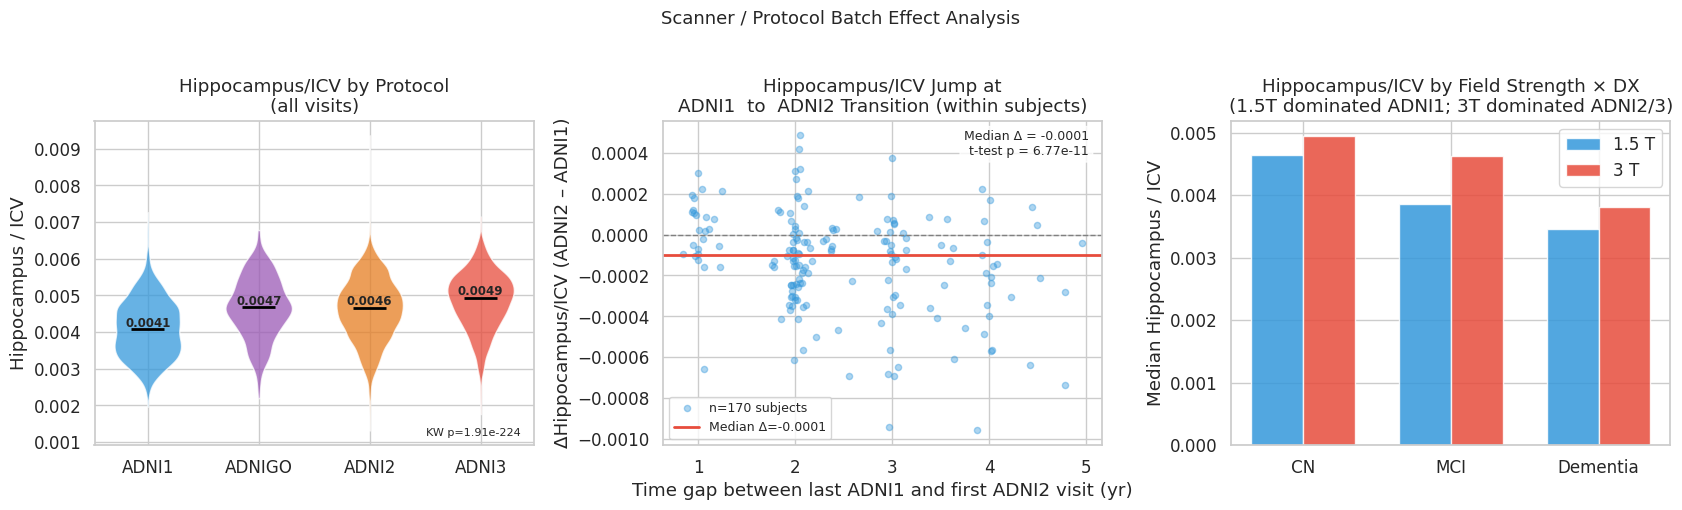


Saved: 17_batch_effects.png


In [ ]:

# ADNI Study / Scanner Batch Effect Check

df["Hippocampus_ICV"] = df["Hippocampus"] / df["ICV"]

PROTO_ORDER  = ["ADNI1", "ADNIGO", "ADNI2", "ADNI3"]
PROTO_COLORS = {"ADNI1": "#3498db", "ADNIGO": "#9b59b6",
                "ADNI2": "#e67e22", "ADNI3": "#e74c3c"}

#17a: hippocampus/ICV distribution by protocol
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Vviolin by protocol
proto_data = [df[df["COLPROT"] == p]["Hippocampus_ICV"].dropna() for p in PROTO_ORDER]
parts = axes[0].violinplot(proto_data, positions=range(4),
                            widths=0.6, showmedians=True, showextrema=False)
for pc, p in zip(parts["bodies"], PROTO_ORDER):
    pc.set_facecolor(PROTO_COLORS[p]); pc.set_alpha(0.75)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(2)

for i, (p, d) in enumerate(zip(PROTO_ORDER, proto_data)):
    axes[0].text(i, d.median(), f"{d.median():.4f}",
                 ha="center", va="bottom", fontsize=8.5, fontweight="bold")

axes[0].set_xticks(range(4)); axes[0].set_xticklabels(PROTO_ORDER)
axes[0].set(title="Hippocampus/ICV by Protocol\n(all visits)",
            ylabel="Hippocampus / ICV")
kw_p = stats.kruskal(*[d for d in proto_data if len(d) > 0]).pvalue
axes[0].text(0.97, 0.03, f"KW p={kw_p:.2e}",
             transform=axes[0].transAxes, ha="right", fontsize=8)

# 17b: within subject protocol transitions
# find subjects who appear in ADNI1 AND ADNI2 (most common transition)
subj_proto = df.groupby("RID")["COLPROT"].apply(set)
transition_rids = subj_proto[subj_proto.apply(lambda s: "ADNI1" in s and "ADNI2" in s)].index

transition_rows = []
for rid in transition_rids:
    subj = df[(df["RID"] == rid) & df["Hippocampus_ICV"].notna()].copy()
    adni1_visits = subj[subj["COLPROT"] == "ADNI1"].sort_values("Years_bl")
    adni2_visits = subj[subj["COLPROT"] == "ADNI2"].sort_values("Years_bl")
    if len(adni1_visits) == 0 or len(adni2_visits) == 0:
        continue
    last_adni1  = adni1_visits.iloc[-1]
    first_adni2 = adni2_visits.iloc[0]
    time_gap    = first_adni2["Years_bl"] - last_adni1["Years_bl"]
    if time_gap < 0 or time_gap > 5:  # skip anomalies
        continue
    transition_rows.append({
        "RID":        rid,
        "last_ADNI1": last_adni1["Hippocampus_ICV"],
        "first_ADNI2": first_adni2["Hippocampus_ICV"],
        "time_gap":   time_gap,
        "DX_bl":      last_adni1["DX_bl"],
    })

trans_df = pd.DataFrame(transition_rows).dropna()
trans_df["delta"] = trans_df["first_ADNI2"] - trans_df["last_ADNI1"]
trans_df["annual_delta"] = trans_df["delta"] / trans_df["time_gap"].clip(lower=0.1)

print(f"\nWithin-subject ADNI1 to ADNI2 transitions: {len(trans_df)}")
print(f"  Median Hippocampus/ICV jump at transition: {trans_df['delta'].median():.5f}")
print(f"  (positive = apparent increase at transition; "
      f"expected biological change ≈ {trans_df['annual_delta'].median() * trans_df['time_gap'].mean():.5f})")
_, t_p = stats.ttest_1samp(trans_df["delta"], 0)
print(f"  One-sample t-test vs. 0: p={t_p:.4e}")

axes[1].scatter(trans_df["time_gap"], trans_df["delta"],
                alpha=0.4, s=20, color="#3498db",
                label=f"n={len(trans_df)} subjects")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].axhline(trans_df["delta"].median(), color="#e74c3c", linestyle="-",
                linewidth=2, label=f"Median Δ={trans_df['delta'].median():.4f}")
axes[1].set(title="Hippocampus/ICV Jump at\nADNI1  to  ADNI2 Transition (within subjects)",
            xlabel="Time gap between last ADNI1 and first ADNI2 visit (yr)",
            ylabel="ΔHippocampus/ICV (ADNI2 – ADNI1)")
axes[1].legend(fontsize=9)

# distribution of the delta
axes[1].text(0.97, 0.97,
             f"Median Δ = {trans_df['delta'].median():.4f}\n"
             f"t-test p = {t_p:.2e}",
             transform=axes[1].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# T5c: field strength effect within DX
fs_order = ["1.5 Tesla MRI", "3 Tesla MRI"]
fs_colors = {"1.5 Tesla MRI": "#3498db", "3 Tesla MRI": "#e74c3c"}
fs_labels = {"1.5 Tesla MRI": "1.5 T", "3 Tesla MRI": "3 T"}

print("\nField strength × DX median Hippocampus/ICV:")
xs = np.arange(len(DX_ORDER))
width = 0.35
for i, fs in enumerate(fs_order):
    meds = []
    for dx in DX_ORDER:
        sub = df[(df["DX_bl"] == dx) & (df["FLDSTRENG"] == fs)]["Hippocampus_ICV"].dropna()
        meds.append(sub.median() if len(sub) > 0 else np.nan)
        print(f"  {dx:8s} {fs_labels[fs]:4s}: median={meds[-1]:.5f}  n={len(sub)}")
    axes[2].bar(xs + i * width - width / 2, meds, width,
                label=fs_labels[fs], color=fs_colors[fs],
                edgecolor="white", alpha=0.85)

axes[2].set_xticks(xs); axes[2].set_xticklabels(DX_ORDER)
axes[2].set(title="Hippocampus/ICV by Field Strength × DX\n"
            "(1.5T dominated ADNI1; 3T dominated ADNI2/3)",
            ylabel="Median Hippocampus / ICV")
axes[2].legend()

plt.suptitle("Scanner / Protocol Batch Effect Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/17_batch_effects.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: 17_batch_effects.png")

# 18: Cognitive Trajectory Stability in Baseline-CN Subjects

### Figure:
Three-panel figure. Left: individual MMSE trajectories for CN subjects coloured by eventual outcome (Stable CN green, CN to MCI orange, CN to Dementia red), with group mean ± SE overlaid. Centre: histogram of per-subject MMSE slopes by CN outcome. Right: histogram of per-subject Logical Memory (LDELTOTAL) slopes by CN outcome.

### Observations:
Left panel (individual trajectories): The sheer mass of overlapping green trajectories — stable CN subjects who maintain MMSE near 29–30 for over a decade — dominates the plot. The CN to MCI mean (orange) tracks close to the Stable CN mean until approximately year 4–5, then begins to diverge, reflecting the gradual onset of measurable cognitive change. The CN to Dementia mean (red) is the most dramatic: it follows Stable CN through year 6, then collapses steeply below the MMSE = 24 clinical threshold and continues declining to the low 20s and below by year 12.

This late divergence is a core challenge of preclinical AD prediction: for the first several years of follow-up, eventual converters look clinically indistinguishable from stable subjects on MMSE alone. This motivates the use of more sensitive early markers (CDR-SB slope, CSF Aβ) rather than relying on MMSE.
Centre panel (MMSE slopes): The CN to Dementia group shows a bimodal-like pattern with a peak near 0 (subjects who were stable for years before rapid decline) and a secondary mass at −2 to −4 pts/year. The CN to MCI group's median slope is shifted slightly left of Stable CN, but the distributions overlap substantially. The clinical threshold of −1 pts/year correctly excludes most Stable CN subjects but catches only a modest fraction of CN to MCI converters — sensitivity would be low.

Right panel (Logical Memory slopes): The LDELTOTAL slope distributions show a similar pattern to MMSE but with greater overall spread. All three groups have wide distributions, and the CN to Dementia group shifts left (toward faster decline) with a longer negative tail. The CN to MCI group's distribution sits intermediate, with its median slightly more negative than Stable CN but with enormous overlap.

### Modelling Implications:

The late-divergence pattern in individual trajectories confirms that predicting CN to MCI requires accumulating information over at least 2–3 years of follow-up before the signal becomes detectable in most subjects. Single-timepoint prediction is severely limited.

A model architecture that can incorporate the full historical trajectory (e.g., LSTM or Transformer with time-aware positional encoding) has a genuine advantage over cross-sectional models for the CN to MCI task.

The small CN to Dementia group (n = 38) should be monitored for class imbalance effects during training; their dramatic trajectory may exert disproportionate influence.

CN subjects with ≥3 MMSE observations: 614
  Stable CN : 476
  CN to MCI    : 100
  CN to Dem    : 38

Proportion of CN subjects declining below threshold (MMSE < −1 pts/yr):
  Stable CN           : 4.9%  (n=590)
  CN to MCI           : 8.3%  (n=108)
  CN to Dementia      : 28.9%  (n=38)


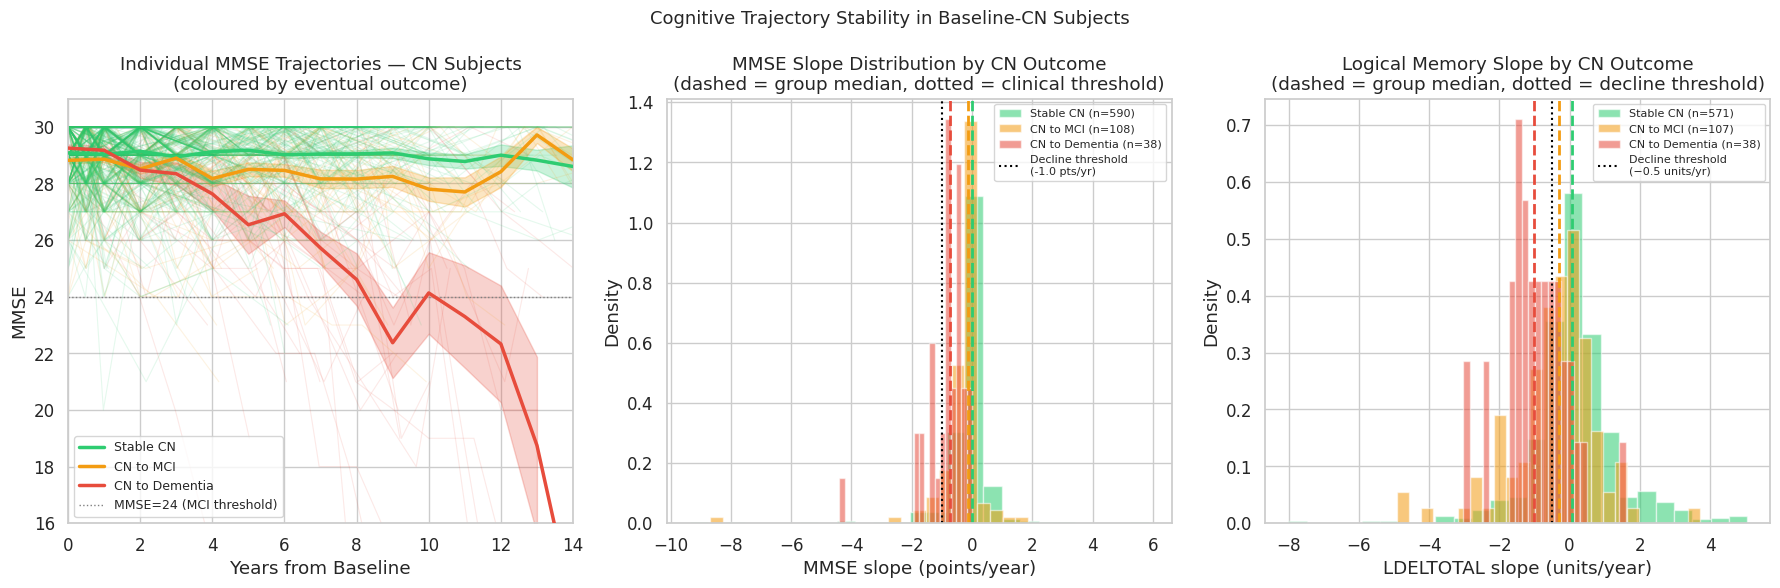


Saved: 18_cn_cognitive_stability.png


In [ ]:
#18: Cognitive Stability in CN Subjects

CN_OUTCOME_PAL = {"Stable CN": "#2ecc71", "CN to MCI": "#f39c12", "CN to Dementia": "#e74c3c"}
MAX_FOLLOW_UP  = 14  # years

cn_long_cog = cn_long.dropna(subset=["Years_bl"]).copy()
cn_long_cog["cn_outcome"] = cn_long_cog["RID"].map(cn_conv)

# require at least 3 MMSE observations to plot trajectory
mmse_counts = cn_long_cog.dropna(subset=["MMSE"]).groupby("RID")["MMSE"].count()
rids_enough = mmse_counts[mmse_counts >= 3].index
cn_plot     = cn_long_cog[cn_long_cog["RID"].isin(rids_enough)]

print(f"CN subjects with ≥3 MMSE observations: {len(rids_enough)}")
print(f"  Stable CN : {(cn_plot.groupby('RID')['cn_outcome'].first()=='Stable CN').sum()}")
print(f"  CN to MCI    : {(cn_plot.groupby('RID')['cn_outcome'].first()=='CN to MCI').sum()}")
print(f"  CN to Dem    : {(cn_plot.groupby('RID')['cn_outcome'].first()=='CN to Dementia').sum()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# T6a: Individual MMSE trajectories
for outcome, group in cn_plot.groupby("cn_outcome"):
    color = CN_OUTCOME_PAL.get(outcome, "gray")
    for rid, subj in group.groupby("RID"):
        subj_sorted = subj.dropna(subset=["MMSE"]).sort_values("Years_bl")
        if len(subj_sorted) < 2:
            continue
        axes[0].plot(subj_sorted["Years_bl"], subj_sorted["MMSE"],
                     color=color, alpha=0.12, linewidth=0.8)

#Overlay group means
for outcome in ["Stable CN", "CN to MCI", "CN to Dementia"]:
    sub = cn_plot[cn_plot["cn_outcome"] == outcome].dropna(subset=["MMSE"])
    binned = (sub.assign(year_bin=sub["Years_bl"].round(0))
              .groupby("year_bin")["MMSE"]
              .agg(["mean", "sem"]).reset_index())
    binned = binned[binned["year_bin"] <= MAX_FOLLOW_UP]
    color  = CN_OUTCOME_PAL[outcome]
    axes[0].plot(binned["year_bin"], binned["mean"], color=color,
                 linewidth=2.5, label=outcome, zorder=5)
    axes[0].fill_between(binned["year_bin"],
                         binned["mean"] - binned["sem"],
                         binned["mean"] + binned["sem"],
                         alpha=0.25, color=color)

axes[0].axhline(24, color="gray", linestyle=":", linewidth=1,
                label="MMSE=24 (MCI threshold)")
axes[0].set(title="Individual MMSE Trajectories — CN Subjects\n"
            "(coloured by eventual outcome)",
            xlabel="Years from Baseline", ylabel="MMSE",
            xlim=(0, MAX_FOLLOW_UP), ylim=(16, 31))
axes[0].legend(fontsize=9)

# 18b: MMSE slope distribution by CN outcome
# use slopes already computed in Cell T1 if available otherwise recompute
if "slopes_df" in dir():
    cn_slope_sub = slopes_df[slopes_df["DX_bl"] == "CN"].copy()
    cn_slope_sub["cn_outcome"] = cn_slope_sub["RID"].map(cn_conv)
else:
    # fallback: recompute MMSE slopes for CN subject
    cn_slope_rows = []
    for rid, grp in cn_long.groupby("RID"):
        sub = grp[["Years_bl", "MMSE"]].dropna()
        if len(sub) >= 2 and sub["Years_bl"].nunique() >= 2:
            slope, *_ = _stats.linregress(sub["Years_bl"], sub["MMSE"])
            cn_slope_rows.append({"RID": rid, "slope_MMSE": slope})
    cn_slope_sub = pd.DataFrame(cn_slope_rows)
    cn_slope_sub["cn_outcome"] = cn_slope_sub["RID"].map(cn_conv)

CLINICALLY_MEANINGFUL_MMSE_DECLINE = -1.0  #points per year

for outcome in ["Stable CN", "CN to MCI", "CN to Dementia"]:
    sub = cn_slope_sub[cn_slope_sub["cn_outcome"] == outcome]["slope_MMSE"].dropna()
    if len(sub) < 5:
        continue
    color = CN_OUTCOME_PAL[outcome]
    axes[1].hist(sub, bins=25, alpha=0.55, color=color,
                 label=f"{outcome} (n={len(sub)})", density=True)
    axes[1].axvline(sub.median(), color=color, linewidth=2,
                    linestyle="--")

axes[1].axvline(CLINICALLY_MEANINGFUL_MMSE_DECLINE, color="black",
                linewidth=1.5, linestyle=":",
                label=f"Decline threshold\n({CLINICALLY_MEANINGFUL_MMSE_DECLINE} pts/yr)")
axes[1].set(title="MMSE Slope Distribution by CN Outcome\n"
            "(dashed = group median, dotted = clinical threshold)",
            xlabel="MMSE slope (points/year)", ylabel="Density")
axes[1].legend(fontsize=8)

#18c: LDELTOTAL slope distribution by CN outcome
if "slopes_df" in dir():
    slope_col = "slope_LDELTOTAL"
    has_slope_col = slope_col in slopes_df.columns
else:
    has_slope_col = False

if has_slope_col:
    cn_slope_sub["slope_LDELTOTAL"] = cn_slope_sub["RID"].map(
        slopes_df.set_index("RID")["slope_LDELTOTAL"])
    lm_col = "slope_LDELTOTAL"
else:
    # recompute LDELTOTAL slopes
    lm_slopes = {}
    for rid, grp in cn_long.groupby("RID"):
        sub = grp[["Years_bl", "LDELTOTAL"]].dropna()
        if len(sub) >= 2 and sub["Years_bl"].nunique() >= 2:
            slope, *_ = _stats.linregress(sub["Years_bl"], sub["LDELTOTAL"])
            lm_slopes[rid] = slope
    cn_slope_sub["slope_LDELTOTAL"] = cn_slope_sub["RID"].map(lm_slopes)
    lm_col = "slope_LDELTOTAL"

for outcome in ["Stable CN", "CN to MCI", "CN to Dementia"]:
    sub = cn_slope_sub[cn_slope_sub["cn_outcome"] == outcome][lm_col].dropna()
    if len(sub) < 5:
        continue
    color = CN_OUTCOME_PAL[outcome]
    axes[2].hist(sub, bins=25, alpha=0.55, color=color,
                 label=f"{outcome} (n={len(sub)})", density=True)
    axes[2].axvline(sub.median(), color=color, linewidth=2, linestyle="--")

axes[2].axvline(-0.5, color="black", linewidth=1.5, linestyle=":",
                label="Decline threshold\n(−0.5 units/yr)")
axes[2].set(title="Logical Memory Slope by CN Outcome\n"
            "(dashed = group median, dotted = decline threshold)",
            xlabel="LDELTOTAL slope (units/year)", ylabel="Density")
axes[2].legend(fontsize=8)

# print proportion declining at each threshold
print("\nProportion of CN subjects declining below threshold (MMSE < −1 pts/yr):")
for outcome in ["Stable CN", "CN to MCI", "CN to Dementia"]:
    sub = cn_slope_sub[cn_slope_sub["cn_outcome"] == outcome]["slope_MMSE"].dropna()
    if len(sub) < 5:
        continue
    pct = (sub < CLINICALLY_MEANINGFUL_MMSE_DECLINE).mean() * 100
    print(f"  {outcome:20s}: {pct:.1f}%  (n={len(sub)})")

plt.suptitle("Cognitive Trajectory Stability in Baseline-CN Subjects", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/18_cn_cognitive_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: 18_cn_cognitive_stability.png")

# 19a: Feature Completeness Heatmap by Visit Code

### Figure:
Heatmap with features (rows, grouped by Cognitive / MRI / PET / CSF / Genetic) on the y-axis and visit codes (BL through M120) on the x-axis. Cell values show the percentage of subjects with valid data at that visit.

### Observations:
The heatmap makes the three-tier data availability structure immediately legible:

- Tier 1, Always available (dark green): The cognitive battery (MMSE, CDR-SB, FAQ, RAVLT) maintains 80–100% coverage at all standard visits (BL, M06, M12, M24, M36, M48+). The notable exception is Logical Memory, which drops to 0% at M06 and 1% at M18 — this sub-test was not administered at all odd-year 6-month visits in certain ADNI phases, creating structural gaps. APOE4 is near-100% once collected. This tier is the backbone of any longitudinal model.
- Tier 2, Episodically available ( about 40–77%): MRI-derived features (Hippocampus, Entorhinal, Ventricles) are available at most standard visits at baseline (86%) but drop sharply at M18 ( about 18%) and more modestly at M36 ( about 39%). The biennial imaging schedule is clearly visible. MoCA is structurally incomplete in early visits (65% at BL, 51% at M06, 49% at M12) because it was introduced to the ADNI protocol in later phases — a clear protocol-phase confound.
- Tier 3, Sparse after baseline (red): CSF Aβ, CSF Tau, and CSF p-Tau are each available for  about 50% of subjects at baseline but fall to 0% at M06, recover to  about 28% at M24, then drop below 10% for all subsequent visits. PET modalities follow a similar pattern, with additional within-visit variation reflecting which PET types were acquired at each protocol time point. The AV45-PET column shows an unusual spike at M48 (47%) reflecting the specific amyloid PET protocol in ADNI2.

The M18 column (across all features) is particularly sparse — this is a non-standard intermediate visit added in some ADNI phases. The yellow/orange colour across that entire column signals that M18 data should be used with caution in longitudinal analyses.

### Modelling Implications:

This heatmap should be included in the final report as the primary justification for all data imputation and modelling decisions.
The practical implication: any model that requires CSF or PET at follow-up visits is unfeasible for most subjects. These modalities should be treated as baseline-only features.

Logical Memory's structural gap at M06 means that using Logical Memory as a predictor in models that train on 6-month data requires careful handling (this is not random missingness — it should not be imputed).

MoCA's protocol-phase incompleteness means it should either be excluded from longitudinal analyses or treated as a protocol-stratified feature.


---



# 19b: Feature Completeness Over Time: Line Plots

### Figure:
Two line charts. Left: completeness over time for cognitive measures (MMSE, CDR-SB, Logical Memory) and MRI measures (Hippocampus, Entorhinal, Ventricles). Right: completeness over time for PET (FDG, AV45, FBB) and CSF (Aβ, Tau, p-Tau) measures.

### Observations:
Left panel (Cognitive & MRI): Cognitive measures form a stable cluster at 80–100% through M72, with the M18 valley visible across all measures. Logical Memory (purple) is the outlier, dropping to near-zero at M06 and M18. MRI measures (dashed lines) track around 60–85% at major visits but consistently lag behind cognitive measures by 10–20 percentage points and show larger oscillations. The divergence between solid (cognitive) and dashed (MRI) lines grows at later visits (M96–M120), reflecting differential dropout of subjects from the imaging sub-studies.

Right panel (PET & CSF): The entire right panel is shaded red to emphasise that all modalities here are below 50% for most of the follow-up period. The patterns are noisy and spiky due to small sample sizes at later visits. FDG-PET (red) is the highest-coverage PET modality and shows episodic peaks corresponding to imaging windows in each ADNI protocol phase. AV45-PET (orange) is notably absent at early visits then becomes relatively more available from M24 onwards. CSF measures (dashed green, blue, teal) stay below 30% at all follow-up visits.

The convergence of all lines toward the right of the plot (M108–M120) partly reflects survivor bias — only the most consistently followed subjects reach 9–10 years of follow-up, and these subjects tend to be the most engaged participants with higher overall data completeness.

### Modelling Implications:

The line chart makes the practical decision clearer than the heatmap: if building a model that uses longitudinal features from multiple modalities, the usable longitudinal time window for full multimodal data is essentially baseline to M24 (approximately 2 years). Beyond that, the only reliable longitudinal signal comes from cognitive scores.
For a 3–5 year prediction window, this means: use baseline PET/CSF as features, use longitudinal cognitive slopes as features, and use MRI at baseline + M24 where available.

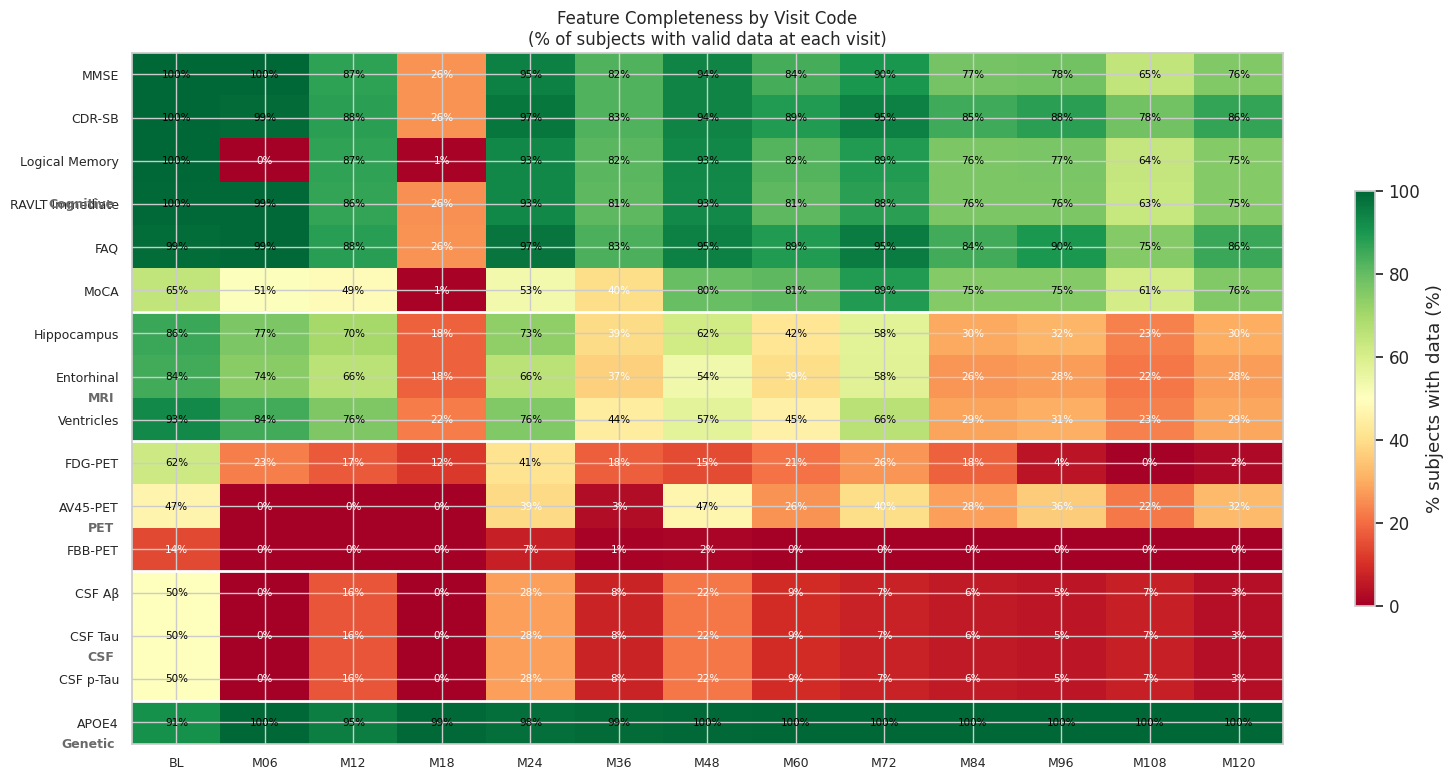

Saved: 19a_completeness_heatmap.png


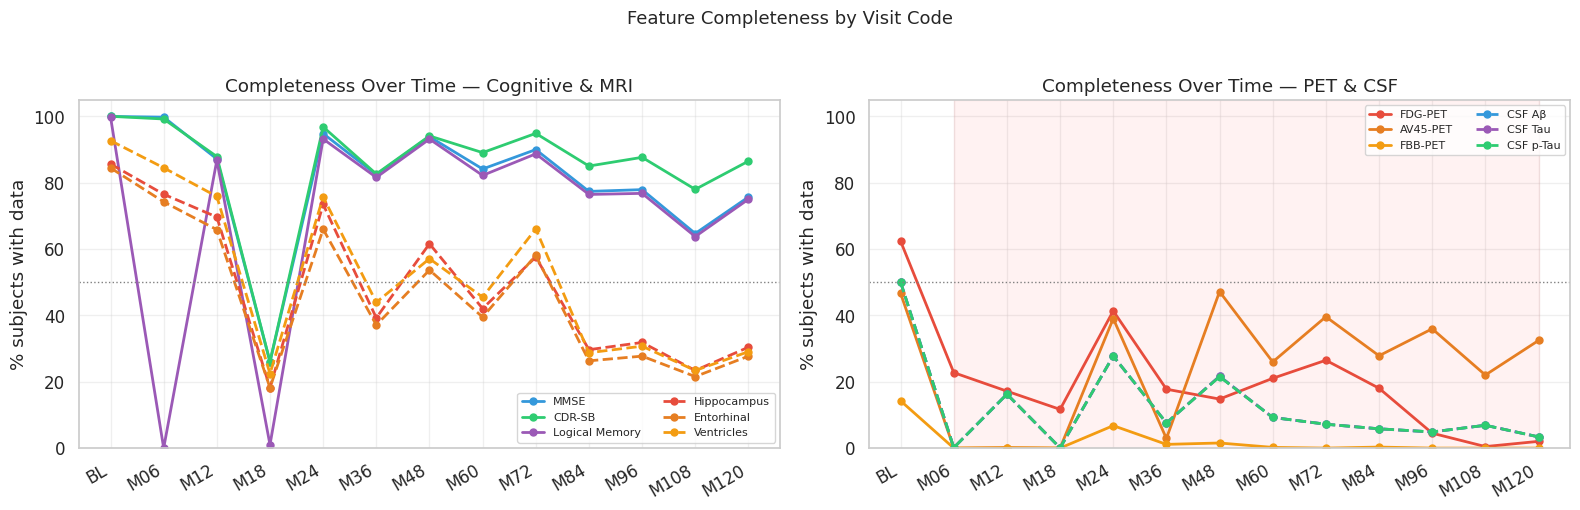

Saved: 19b_completeness_lines.png

── Key feature completeness by visit (%) ──
                bl    m06   m12   m18   m24   m36    m48    m60    m72    m84    m96   m108   m120
MMSE         100.0  100.0  87.0  26.0  95.0  82.0   94.0   84.0   90.0   77.0   78.0   65.0   76.0
Hippocampus   86.0   77.0  70.0  18.0  73.0  39.0   62.0   42.0   58.0   30.0   32.0   23.0   30.0
FDG           62.0   23.0  17.0  12.0  41.0  18.0   15.0   21.0   26.0   18.0    4.0    0.0    2.0
AV45          47.0    0.0   0.0   0.0  39.0   3.0   47.0   26.0   40.0   28.0   36.0   22.0   32.0
ABETA         50.0    0.0  16.0   0.0  28.0   8.0   22.0    9.0    7.0    6.0    5.0    7.0    3.0
APOE4         91.0  100.0  95.0  99.0  98.0  99.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0


In [ ]:
#19:Feature completeness by visit Code


VISIT_ORDER = ["bl", "m06", "m12", "m18", "m24", "m36",
               "m48", "m60", "m72", "m84", "m96", "m108", "m120"]
VISIT_LABELS = [v.replace("m", "M").replace("bl", "BL") for v in VISIT_ORDER]

COMPLETENESS_FEATURES = {
    #cognitive
    "MMSE":            "MMSE",
    "CDRSB":           "CDR-SB",
    "LDELTOTAL":       "Logical Memory",
    "RAVLT_immediate": "RAVLT Immediate",
    "FAQ":             "FAQ",
    "MOCA":            "MoCA",
    #MRI
    "Hippocampus":     "Hippocampus",
    "Entorhinal":      "Entorhinal",
    "Ventricles":      "Ventricles",
    #PET
    "FDG":             "FDG-PET",
    "AV45":            "AV45-PET",
    "FBB":             "FBB-PET",
    #CSF
    "ABETA":           "CSF Aβ",
    "TAU":             "CSF Tau",
    "PTAU":            "CSF p-Tau",
    #Genetic (static. should be 100% once collected)
    "APOE4":           "APOE4",
}

df_v = df[df["VISCODE"].isin(VISIT_ORDER)].copy()
# reparse CSF in visit frame
for col in ["ABETA", "TAU", "PTAU"]:
    df_v[col] = pd.to_numeric(
        df_v[col].astype(str).str.replace(r"[><]", "", regex=True).str.strip(),
        errors="coerce"
    )

# build completeness matrix (features × visits)
comp_matrix = pd.DataFrame(index=COMPLETENESS_FEATURES.keys(), columns=VISIT_ORDER, dtype=float)
for feat in COMPLETENESS_FEATURES:
    if feat not in df_v.columns:
        continue
    by_visit = df_v.groupby("VISCODE")[feat].apply(lambda x: x.notna().mean() * 100)
    comp_matrix.loc[feat] = by_visit.reindex(VISIT_ORDER).values

comp_matrix = comp_matrix.astype(float)

# 19a: heatmap
fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(comp_matrix.values, aspect="auto", cmap="RdYlGn",
               vmin=0, vmax=100, interpolation="nearest")

ax.set_xticks(range(len(VISIT_ORDER)))
ax.set_xticklabels(VISIT_LABELS, fontsize=9)
ax.set_yticks(range(len(COMPLETENESS_FEATURES)))
ax.set_yticklabels(list(COMPLETENESS_FEATURES.values()), fontsize=9)

#annotate cells
for i in range(len(COMPLETENESS_FEATURES)):
    for j in range(len(VISIT_ORDER)):
        val = comp_matrix.values[i, j]
        if not np.isnan(val):
            text_color = "black" if val > 40 else "white"
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                    fontsize=7.5, color=text_color)

#group separators (cognitive / MRI / PET / CSF / genetic)
group_boundaries = [6, 9, 12, 15]
for b in group_boundaries:
    ax.axhline(b - 0.5, color="white", linewidth=2)

group_labels = ["Cognitive", "MRI", "PET", "CSF", "Genetic"]
group_centers = [3, 7.5, 10.5, 13.5, 15.5]
for label, center in zip(group_labels, group_centers):
    ax.text(-0.7, center, label, ha="right", va="center",
            fontsize=9, fontweight="bold", color="dimgray")

plt.colorbar(im, ax=ax, label="% subjects with data (%)", shrink=0.6)
ax.set_title("Feature Completeness by Visit Code\n"
             "(% of subjects with valid data at each visit)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/19a_completeness_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 19a_completeness_heatmap.png")

# 19b: Line chart: grouped by modality type
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: cognitive + MRI (high availability group)
hi_avail = {
    "MMSE": ("#3498db", "-"),
    "CDRSB": ("#2ecc71", "-"),
    "LDELTOTAL": ("#9b59b6", "-"),
    "Hippocampus": ("#e74c3c", "--"),
    "Entorhinal": ("#e67e22", "--"),
    "Ventricles": ("#f39c12", "--"),
}
for feat, (color, ls) in hi_avail.items():
    vals = comp_matrix.loc[feat]
    label = COMPLETENESS_FEATURES[feat]
    axes[0].plot(range(len(VISIT_ORDER)), vals.values, marker="o",
                 color=color, linestyle=ls, linewidth=2, markersize=5, label=label)

axes[0].set_xticks(range(len(VISIT_ORDER)))
axes[0].set_xticklabels(VISIT_LABELS, rotation=30, ha="right")
axes[0].set(title="Completeness Over Time — Cognitive & MRI",
            ylabel="% subjects with data", ylim=(0, 105))
axes[0].axhline(50, color="gray", linestyle=":", linewidth=1)
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)

# Right: PET + CSF (sparse group)
lo_avail = {
    "FDG": ("#e74c3c", "-"),
    "AV45": ("#e67e22", "-"),
    "FBB": ("#f39c12", "-"),
    "ABETA": ("#3498db", "--"),
    "TAU": ("#9b59b6", "--"),
    "PTAU": ("#2ecc71", "--"),
}
for feat, (color, ls) in lo_avail.items():
    vals = comp_matrix.loc[feat]
    label = COMPLETENESS_FEATURES[feat]
    axes[1].plot(range(len(VISIT_ORDER)), vals.values, marker="o",
                 color=color, linestyle=ls, linewidth=2, markersize=5, label=label)

axes[1].set_xticks(range(len(VISIT_ORDER)))
axes[1].set_xticklabels(VISIT_LABELS, rotation=30, ha="right")
axes[1].set(title="Completeness Over Time — PET & CSF",
            ylabel="% subjects with data", ylim=(0, 105))
axes[1].axhline(50, color="gray", linestyle=":", linewidth=1)
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)

#Shade the critical "after baseline" region for CSF
axes[1].axvspan(1, len(VISIT_ORDER) - 1, alpha=0.05, color="red",
                label="CSF near-absent after baseline")

plt.suptitle("Feature Completeness by Visit Code", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/19b_completeness_lines.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 19b_completeness_lines.png")

# Print key rows as a table
print("\n── Key feature completeness by visit (%) ──")
key_rows = ["MMSE", "Hippocampus", "FDG", "AV45", "ABETA", "APOE4"]
print(comp_matrix.loc[key_rows].round(0).to_string())

# 20: PET & CSF Cross Modality Correlation


---


### Figure:
Three scatter plots showing: (1) CSF Amyloid-β vs. AV45-PET SUVR, (2) CSF Tau vs. FDG-PET SUVR, (3) CSF Amyloid-β vs. FDG-PET SUVR. Each includes per-DX regression lines (solid) and an overall regression line (dashed). Spearman r and p-values annotated.

### Observations:
Panel 1 (CSF Aβ vs. AV45-PET): The strongest cross-modality correlation in the dataset: Spearman r = −0.685 (p ≈ 4×10⁻¹¹³, n = 809). The negative sign reflects the inverse relationship — lower CSF Aβ (more amyloid stuck in plaques, less in CSF) corresponds to higher AV45 SUVR (more amyloid detected by PET). The within-DX regression lines are nearly parallel and show that this relationship holds across all three groups. The scatter within each group is substantial but the overall trend is unmistakable. This confirms that CSF Aβ and amyloid PET are measuring the same underlying biology — amyloid burden — through complementary windows. For subjects missing one modality, the other provides similar information.

Panel 2 (CSF Tau vs. FDG-PET): Much weaker correlation: r = −0.310 (p ≈ 6×10⁻²⁴). The scatter is far greater and the regression lines have much shallower slopes. This makes biological sense: CSF tau reflects neuronal damage and tangle burden, while FDG-PET reflects metabolic activity — related but downstream of each other through different mechanisms. The Dementia group (red) shows the widest tau range and the lowest FDG values, as expected. The weaker correlation means CSF tau and FDG-PET carry more complementary information than CSF Aβ and amyloid PET do.

Panel 3 (CSF Aβ vs. FDG-PET): Moderate positive correlation r = +0.427 (p ≈ 5×10⁻⁴⁶, n = 1008). Higher CSF Aβ (lower amyloid burden, earlier disease) corresponds to higher FDG (better metabolism, healthier tissue). The per-DX lines reveal an interesting pattern: within the CN group, the relationship is nearly flat (FDG doesn't vary much with Aβ when subjects are cognitively normal), but the relationship strengthens in MCI and Dementia groups, consistent with amyloid pathology leading to downstream metabolic decline on a multi-year lag.

### Modelling Implications:

The near-redundancy of CSF Aβ and AV45-PET (r = −0.685) means that in a feature set, including both may not substantially increase information content. A model should either use one, or use their combination as a single "amyloid burden" composite.
The CSF Tau / FDG-PET correlation is weak enough that both are worth including as separate features — they capture genuinely different aspects of neurodegeneration.
Practically, the high CSF Aβ / AV45-PET correlation justifies imputing missing amyloid PET values from CSF Aβ (or vice versa) as a data augmentation strategy, which could increase the effective sample size for amyloid-related features by  about 30%.
The asymmetric per-DX slopes in Panel 3 suggest that the Aβ–FDG relationship is non-stationary across disease stages — nonlinear models or stage-stratified analyses would better capture this than a linear model across the full sample.


CSF Aβ vs. Amyloid-PET
(higher AV45 = more amyloid; lower ABETA = more amyloid)
  N with both: 809
  Overall Spearman r=-0.685, p=4.35e-113
  CN      : r=-0.536, p=3.506e-20, n=252
  MCI     : r=-0.677, p=1.242e-58, n=427
  Dementia: r=-0.272, p=1.758e-03, n=130

CSF Tau vs. FDG-PET
(higher tau = more pathology; lower FDG = more pathology)
  N with both: 1008
  Overall Spearman r=-0.310, p=6.13e-24
  CN      : r=-0.060, p=2.928e-01, n=307
  MCI     : r=-0.210, p=1.384e-06, n=521
  Dementia: r=-0.096, p=1.994e-01, n=180

CSF Aβ vs. FDG-PET
(amyloid upstream, metabolism downstream)
  N with both: 1008
  Overall Spearman r=0.427, p=4.99e-46
  CN      : r=0.141, p=1.329e-02, n=307
  MCI     : r=0.345, p=5.422e-16, n=521
  Dementia: r=0.198, p=7.743e-03, n=180


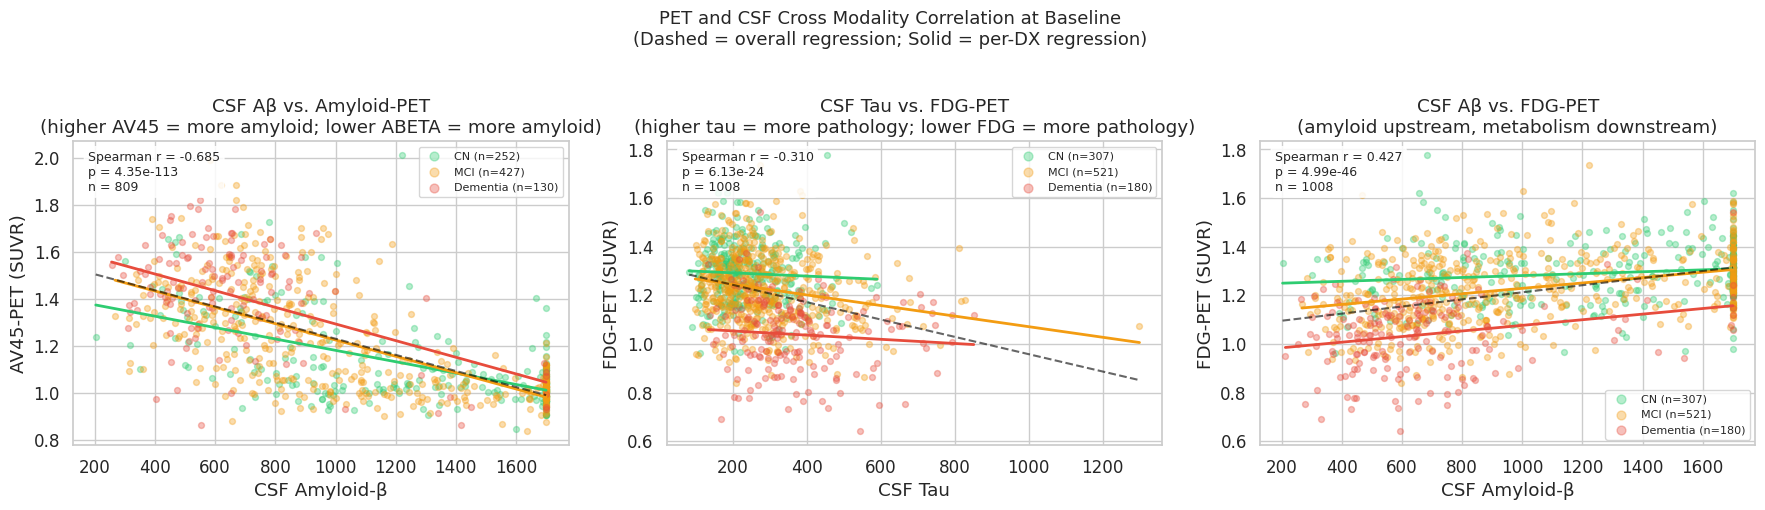


Saved: 20_pet_csf_correlation.png

 Cross modality substitutability summary 
  ABETA  × AV45: r=-0.685  p=4.35e-113  (combining both adds 730 subjects vs. either alone)
  TAU    × FDG : r=-0.310  p=6.13e-24  (combining both adds 714 subjects vs. either alone)
  PTAU   × FDG : r=-0.341  p=8.27e-29  (combining both adds 714 subjects vs. either alone)
  ABETA  × FDG : r=+0.427  p=4.99e-46  (combining both adds 714 subjects vs. either alone)
  TAU    × AV45: r=+0.501  p=9.98e-53  (combining both adds 730 subjects vs. either alone)


In [ ]:

#20 PET n CSF Cross Modality Correlation



PET_CSF_PAIRS = [
    ("ABETA", "AV45",  "CSF Amyloid-β",  "AV45-PET (SUVR)",
     "CSF Aβ vs. Amyloid-PET\n(higher AV45 = more amyloid; lower ABETA = more amyloid)"),
    ("TAU",   "FDG",   "CSF Tau",        "FDG-PET (SUVR)",
     "CSF Tau vs. FDG-PET\n(higher tau = more pathology; lower FDG = more pathology)"),
    ("ABETA", "FDG",   "CSF Amyloid-β",  "FDG-PET (SUVR)",
     "CSF Aβ vs. FDG-PET\n(amyloid upstream, metabolism downstream)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (csf_col, pet_col, csf_label, pet_label, title) in zip(axes, PET_CSF_PAIRS):
    sub = df_bl.dropna(subset=[csf_col, pet_col, "DX_bl"]).copy()
    sub = sub[sub["DX_bl"].isin(DX_ORDER)]

    print(f"\n{title}")
    print(f"  N with both: {len(sub)}")

    # overall spearman correlation
    r_all, p_all = spearmanr(sub[csf_col], sub[pet_col])
    print(f"  Overall Spearman r={r_all:.3f}, p={p_all:.2e}")

    for dx in DX_ORDER:
        dx_sub = sub[sub["DX_bl"] == dx]
        if len(dx_sub) < 10:
            continue
        ax.scatter(dx_sub[csf_col], dx_sub[pet_col],
                   color=DX_PALETTE[dx], alpha=0.35, s=18,
                   label=f"{dx} (n={len(dx_sub)})")
        # Per-DX regression line
        m, b, *_ = stats.linregress(dx_sub[csf_col].values,
                                     dx_sub[pet_col].values)
        x_range = np.linspace(dx_sub[csf_col].min(), dx_sub[csf_col].max(), 50)
        ax.plot(x_range, m * x_range + b,
                color=DX_PALETTE[dx], linewidth=2)

        r_dx, p_dx = spearmanr(dx_sub[csf_col], dx_sub[pet_col])
        print(f"  {dx:8s}: r={r_dx:.3f}, p={p_dx:.3e}, n={len(dx_sub)}")

    # overall regression
    m_all, b_all, *_ = stats.linregress(sub[csf_col].values, sub[pet_col].values)
    x_all = np.linspace(sub[csf_col].min(), sub[csf_col].max(), 100)
    ax.plot(x_all, m_all * x_all + b_all,
            color="black", linewidth=1.5, linestyle="--", alpha=0.6)

    ax.set(xlabel=csf_label, ylabel=pet_label, title=title)
    ax.text(0.03, 0.97, f"Spearman r = {r_all:.3f}\np = {p_all:.2e}\nn = {len(sub)}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))
    ax.legend(fontsize=8, markerscale=1.5)

plt.suptitle("PET and CSF Cross Modality Correlation at Baseline\n"
             "(Dashed = overall regression; Solid = per-DX regression)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/20_pet_csf_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: 20_pet_csf_correlation.png")

# Substitutability summary
print("\n Cross modality substitutability summary ")
pairs_summary = [
    ("ABETA", "AV45"), ("TAU", "FDG"), ("PTAU", "FDG"),
    ("ABETA", "FDG"),  ("TAU", "AV45"),
]
for c1, c2 in pairs_summary:
    sub = df_bl.dropna(subset=[c1, c2])
    if len(sub) < 20:
        continue
    r, p = spearmanr(sub[c1], sub[c2])
    coverage_either = df_bl[c1].notna() | df_bl[c2].notna()
    coverage_both   = df_bl[c1].notna() & df_bl[c2].notna()
    gain = (coverage_either.sum() - coverage_both.sum())
    print(f"  {c1:6s} × {c2:4s}: r={r:+.3f}  p={p:.2e}  "
          f"(combining both adds {gain} subjects vs. either alone)")